## Bivariate and Multivariate Analysis

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import pingouin as pg



pd.set_option("display.max_columns", None)  # Show all columns
pd.set_option("display.width", 1000) 
pd.set_option('display.float_format', '{:.3f}'.format)

## Preparation for Analysis

In [6]:
import os
# Set the working directory to the script's location
os.chdir('/Users/joudisinjab/Documents/GitHub/capstone_project')
LFS = pd.read_csv("Data/LFS.csv")
LFS.head()

,REC_NUM,survey_month,lf_status,province,cmetrop_area,5y_age,2_3y_age,sex,marital_stat,education,multiple_jobh,work_lasty,ft_pt_last,main_class_worker,immigration_stat,NAICS_21,NOC_10,NOC_43,rsn_absent_fullwk,weeks_absent,paid_for_absence,usualhrs_main,actualhrs_main,ft_pt_main,usualhrs_all,actualhrs_all,hrs_away,rsn_away,paid_overtime,unpaid_overtime,hrs_overtime,rsn_pt,current_tenure,prev_tenure,hourly_wage,union_stat,job_permenancy,estab_size,firm_size,duration_unemp,flow_to_unemp,job_seekers_temp_layoffs_status,rsn_left_old,rsn_left_new,duration_jobless,availability,prior_activity,student_status,econ_fam_type,final_wt,REF_DATE,month
0,1,1,4,24,0,12,NaN,2,1,2,NaN,2.000,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,240.000,NaN,NaN,NaN,11,141,2024-01-01,Jan
1,72858,1,1,24,1,8,NaN,1,2,5,1.000,NaN,NaN,2.000,3,12.000,1.000,2.000,NaN,NaN,NaN,35.000,38.000,1.000,35.000,38.000,0.000,NaN,0.000,3.000,3.000,NaN,30.000,NaN,60.440,3.000,1.000,2.000,2.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000,4,419,2024-01-01,Jan
2,72857,1,4,59,0,1,2.000,1,6,3,NaN,3.000,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000,5,234,2024-01-01,Jan
3,72856,1,4,35,4,12,NaN,2,3,4,NaN,2.000,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,240.000,NaN,NaN,NaN,1,224,2024-01-01,Jan
4,72855,1,1,24,2,1,2.000,1,6,2,1.000,NaN,NaN,2.000,3,10.000,7.000,34.000,NaN,NaN,NaN,10.000,10.000,2.000,10.000,10.000,0.000,NaN,0.000,0.000,0.000,4.000,16.000,NaN,16.000,3.000,4.000,2.000,4.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000,3,251,2024-01-01,Jan


In [7]:
LFS.describe()

,REC_NUM,survey_month,lf_status,province,cmetrop_area,5y_age,2_3y_age,sex,marital_stat,education,multiple_jobh,work_lasty,ft_pt_last,main_class_worker,immigration_stat,NAICS_21,NOC_10,NOC_43,rsn_absent_fullwk,weeks_absent,paid_for_absence,usualhrs_main,actualhrs_main,ft_pt_main,usualhrs_all,actualhrs_all,hrs_away,rsn_away,paid_overtime,unpaid_overtime,hrs_overtime,rsn_pt,current_tenure,prev_tenure,hourly_wage,union_stat,job_permenancy,estab_size,firm_size,duration_unemp,flow_to_unemp,job_seekers_temp_layoffs_status,rsn_left_old,rsn_left_new,duration_jobless,availability,prior_activity,student_status,econ_fam_type,final_wt
count,1343036.000,1343036.000,1343036.000,1343036.000,1343036.000,1343036.000,266995.000,1343036.000,1343036.000,1343036.000,789197.000,553839.000,89401.000,878598.000,1343036.000,878598.000,878598.000,878598.000,71835.000,71835.000,65118.000,789197.000,789197.000,789197.000,789197.000,789197.000,622568.000,99885.000,622568.000,622568.000,622568.000,143493.000,789197.000,89401.000,683613.000,683613.000,683613.000,683613.000,683613.000,49491.000,51885.000,51885.000,89401.000,89401.000,463586.000,58349.000,47547.000,999726.000,1343036.000,1343036.000
mean,55966.545,6.524,2.252,34.580,1.747,7.221,3.597,1.513,2.877,3.465,1.056,2.002,1.342,2.122,2.703,13.176,5.189,22.850,1.855,12.989,1.513,35.737,32.073,1.182,36.539,32.781,1.701,2.081,0.817,0.611,1.428,4.110,94.012,61.858,34.611,2.365,1.241,2.208,2.994,17.165,4.502,1.355,3.314,7.567,109.261,1.937,1.584,1.145,6.279,300.364
std,32319.112,3.443,1.416,14.598,2.788,3.602,1.730,0.500,2.175,1.631,0.231,0.570,0.474,1.190,0.591,5.055,2.653,12.738,1.120,21.174,0.500,11.645,16.130,0.386,12.216,16.593,4.925,1.057,3.593,2.796,4.500,1.822,84.158,81.845,18.781,0.920,0.710,1.047,1.164,20.618,2.085,0.567,1.450,3.449,88.635,0.242,0.990,0.402,5.430,277.488
min,1.000,1.000,1.000,10.000,0.000,1.000,1.000,1.000,1.000,0.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,0.000,1.000,1.000,0.100,0.000,1.000,0.100,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,1.000,5.770,1.000,1.000,1.000,1.000,1.000,1.000,1.000,0.000,0.000,1.000,1.000,0.000,1.000,1.000,1.000
25%,27980.000,4.000,1.000,24.000,0.000,4.000,2.000,1.000,1.000,2.000,1.000,2.000,1.000,2.000,3.000,10.000,3.000,10.000,1.000,1.000,1.000,32.500,24.000,1.000,35.000,24.000,0.000,1.000,0.000,0.000,0.000,4.000,21.000,5.000,21.000,1.000,1.000,1.000,2.000,4.000,2.000,1.000,3.000,5.000,24.000,2.000,1.000,1.000,2.000,130.000
50%,55960.000,7.000,1.000,35.000,0.000,7.000,4.000,2.000,2.000,4.000,1.000,2.000,1.000,2.000,3.000,14.000,5.000,24.000,2.000,3.000,2.000,40.000,37.500,1.000,40.000,37.500,0.000,2.000,0.000,0.000,0.000,4.000,63.000,19.000,29.750,3.000,1.000,2.000,4.000,8.000,5.000,1.000,4.000,7.000,90.000,2.000,1.000,1.000,4.000,211.000
75%,83940.000,10.000,4.000,47.000,4.000,11.000,5.000,2.000,6.000,5.000,1.000,2.000,2.000,2.000,3.000,17.000,7.000,34.000,3.000,15.000,2.000,40.000,40.000,1.000,40.000,40.000,0.000,3.000,0.000,0.000,0.000,5.000,163.000,84.000,43.270,3.000,1.000,3.000,4.000,21.000,6.000,2.000,4.000,10.000,198.000,2.000,3.000,1.000,11.000,352.000
max,113108.000,12.000,4.000,59.000,9.000,12.000,6.000,2.000,6.000,6.000,2.000,3.000,2.000,7.000,3.000,21.000,10.000,43.000,3.000,99.000,2.000,99.000,99.000,2.000,99.000,99.000,99.000,4.000,99.000,99.000,99.000,7.000,240.000,240.000,230.770,3.000,4.000,4.000,4.000,99.000,8.000,3.000,5.000,13.000,240.000,2.000,3.000,3.000,18.000,3403.000


In [8]:
LFS.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1343036 entries, 0 to 1343035
Data columns (total 52 columns):
 #   Column                           Non-Null Count    Dtype  
---  ------                           --------------    -----  
 0   REC_NUM                          1343036 non-null  int64  
 1   survey_month                     1343036 non-null  int64  
 2   lf_status                        1343036 non-null  int64  
 3   province                         1343036 non-null  int64  
 4   cmetrop_area                     1343036 non-null  int64  
 5   5y_age                           1343036 non-null  int64  
 6   2_3y_age                         266995 non-null   float64
 7   sex                              1343036 non-null  int64  
 8   marital_stat                     1343036 non-null  int64  
 9   education                        1343036 non-null  int64  
 10  multiple_jobh                    789197 non-null   float64
 11  work_lasty                       553839 non-null  

In [9]:
LFS.duplicated().sum()

0

In [10]:
LFS['REF_DATE'] = pd.to_datetime(LFS['REF_DATE'])
LFS['month'] = LFS['REF_DATE'].dt.strftime('%b')

month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Convert the 'month' column to a categorical type with the specified order
LFS['month'] = pd.Categorical(LFS['month'], categories=month_order, ordered=True)

# Now sorting by 'month' will follow the specified order
LFS_sorted = LFS.sort_values('month')

In [11]:
LFS_numerical = ['weeks_absent', 'usualhrs_main', 'actualhrs_main', 'usualhrs_all', 'actualhrs_all', 
                'hrs_away', 'hrs_overtime', 'paid_overtime','unpaid_overtime', 'current_tenure', 'hourly_wage',  'prev_tenure', 
                 'duration_unemp', 'duration_jobless','LFPR_rate', 'overall_unemp_Rate', 'industry_unemp_rate', 
                 'Job Vacancies (#)', 'Payroll Employees (#)', 'Job Vacancy Rate (%)', 'Inflation_Rate_MoM']

LFS_categorical = ['survey_month', 'lf_status', 'province', 'cmetrop_area', '5y_age', '2_3y_age', 'sex', 
                   'marital_stat', 'education', 'multiple_jobh', 'work_lasty', 'ft_pt_last', 
                   'main_class_worker', 'immigration_stat', 'NAICS_21', 'NOC_10', 'NOC_43', 
                   'rsn_absent_fullwk', 'paid_for_absence', 'ft_pt_main', 'rsn_away', 'rsn_pt', 'union_stat', 
                   'job_permenancy', 'estab_size', 'firm_size', 
                   'flow_to_unemp', 'job_seekers_temp_layoffs_status', 'rsn_left_old', 'rsn_left_new', 'availability'
                   'prior_activity', 'student_status', 'econ_fam_type', 'NAICS_21_JV']

In [12]:
ordinal_vars = [
    'lf_status', '5y_age', '2_3y_age', 'education', 'marital_stat', 'work_lasty',
    'job_permenancy', 'estab_size', 'firm_size', 'student_status' 
]


nominal_vars = [
    'survey_month', 'province', 'cmetrop_area', 'sex', 'multiple_jobh', 
     'ft_pt_last', 'main_class_worker', 'immigration_stat', 
    'NAICS_21', 'NOC_10', 'NOC_43', 'rsn_absent_fullwk', 'ft_pt_main', 
    'rsn_away', 'rsn_pt', 'union_stat', 'flow_to_unemp' , 'availability',
    'job_seekers_temp_layoffs_status', 'rsn_left_old', 'rsn_left_new', 
    'prior_activity', 'econ_fam_type', 'paid_for_absence'
]

# Convert ordinal variables
for var in ordinal_vars:
    LFS[var] = pd.Categorical(LFS[var], ordered=True)  

# Convert nominal variables
for var in nominal_vars:
    LFS[var] = LFS[var].astype('category')

# Check the data types
print(LFS.dtypes)

REC_NUM                                     int64
survey_month                             category
lf_status                                category
province                                 category
cmetrop_area                             category
5y_age                                   category
2_3y_age                                 category
sex                                      category
marital_stat                             category
education                                category
multiple_jobh                            category
work_lasty                               category
ft_pt_last                               category
main_class_worker                        category
immigration_stat                         category
NAICS_21                                 category
NOC_10                                   category
NOC_43                                   category
rsn_absent_fullwk                        category
weeks_absent                              float64


In [13]:
# Employed and At Work View
LFS_atwork = LFS.loc[LFS['lf_status'] == 1]

# Employed but Absent View
LFS_absent = LFS.loc[LFS['lf_status'] == 2]

# All Employed
LFS_employed = LFS.loc[(LFS['lf_status'] == 1) | (LFS['lf_status'] == 2)]

# Unemployed View
LFS_unemployed = LFS.loc[LFS['lf_status'] == 3]

# Not in Force View 
LFS_notinforce = LFS.loc[LFS['lf_status'] == 4]

In [14]:
df = LFS.copy() # As to not clutter main dataset

#### Descriptive stats

In [15]:
descriptive_stats = LFS.describe().T[['mean', 'std', 'min', '50%', 'max']]

# descriptive_stats.to_csv('LFS_Numerical_Stats.csv', index=True)

In [16]:
categorical_cols = LFS.select_dtypes(include=['category', 'object']).columns

summary = []

for col in categorical_cols:
    freq_counts = LFS[col].value_counts()  # Frequency counts
    percentages = (freq_counts / LFS[col].count() * 100).round(2)  # Percentage calculation

    for category, count in freq_counts.items():
        summary.append({
            'Variable': col,
            'Category': category,
            'Frequency (Count)': count,
            'Percentage (%)': percentages[category]
        })

# Convert to DataFrame
categorical_summary = pd.DataFrame(summary)

# Display summary
print(categorical_summary)

# Display summary
print(categorical_summary)


# Save to CSV
# categorical_summary.to_csv("LFS_Categorical_Descriptive_Stats.csv", index=True)


         Variable Category  Frequency (Count)  Percentage (%)
0    survey_month        6             113108           8.420
1    survey_month       11             113107           8.420
2    survey_month        5             112971           8.410
3    survey_month       10             112719           8.390
4    survey_month        7             112699           8.390
..            ...      ...                ...             ...
261         month      Dec             112068           8.340
262         month      Sep             111645           8.310
263         month      Mar             111282           8.290
264         month      Feb             109932           8.190
265         month      Jan             109278           8.140

[266 rows x 4 columns]
         Variable Category  Frequency (Count)  Percentage (%)
0    survey_month        6             113108           8.420
1    survey_month       11             113107           8.420
2    survey_month        5             112971 

## What are the overall trends in Canada’s labour market key indicators in 2024? What is the labour force participation rate and unemployment rate from in 2024? Are there notable trends, and is there a relationship between labour force participation rate, unemployment, and inflation? 

In [17]:
# Loading data and observing the first few rows
overall_indicators = pd.read_csv('Data/Monthly Labour Market Rates.csv')
overall_indicators['REF_DATE'] = pd.to_datetime(overall_indicators['REF_DATE'])
overall_indicators['Month'] = overall_indicators['REF_DATE'].dt.strftime('%b')

# Adding a one month lagged inflation rate variable to the dataset
overall_indicators['Inflation_Rate_Lag1'] = overall_indicators['Inflation_Rate_MoM'].shift(1)
overall_indicators.head()


,Unnamed: 0,REF_DATE,Employment Rate (%),Unemployment Rate (%),Labour Force Participation Rate (%),Unemployed,Average Hourly Wage,combined_industries,Job Vacancies (#),Payroll Employees (#),Job Vacancy Rate (%),All-items,Inflation_Rate_MoM,Market_Tightness,Month,Inflation_Rate_Lag1
0,0,2024-01-01,60.585,6.141,64.549,1311310,34.749,"Total, all industries",662905.000,17182760.000,3.700,159.300,-0.125,0.506,Jan,NaN
1,1,2024-02-01,60.780,6.046,64.691,1297139,34.820,"Total, all industries",659070.000,17235150.000,3.700,159.500,0.126,0.508,Feb,-0.125
2,2,2024-03-01,60.732,6.442,64.914,1390601,34.811,"Total, all industries",602470.000,17241295.000,3.400,159.900,0.251,0.433,Mar,0.126
3,3,2024-04-01,61.064,6.227,65.119,1352940,34.947,"Total, all industries",592915.000,17266410.000,3.300,160.200,0.188,0.438,Apr,0.251
4,4,2024-05-01,61.917,6.291,66.074,1390949,34.939,"Total, all industries",571315.000,17269645.000,3.200,160.600,0.250,0.411,May,0.188


Creating a sub-lineplots to observe trends in each labour market indicator

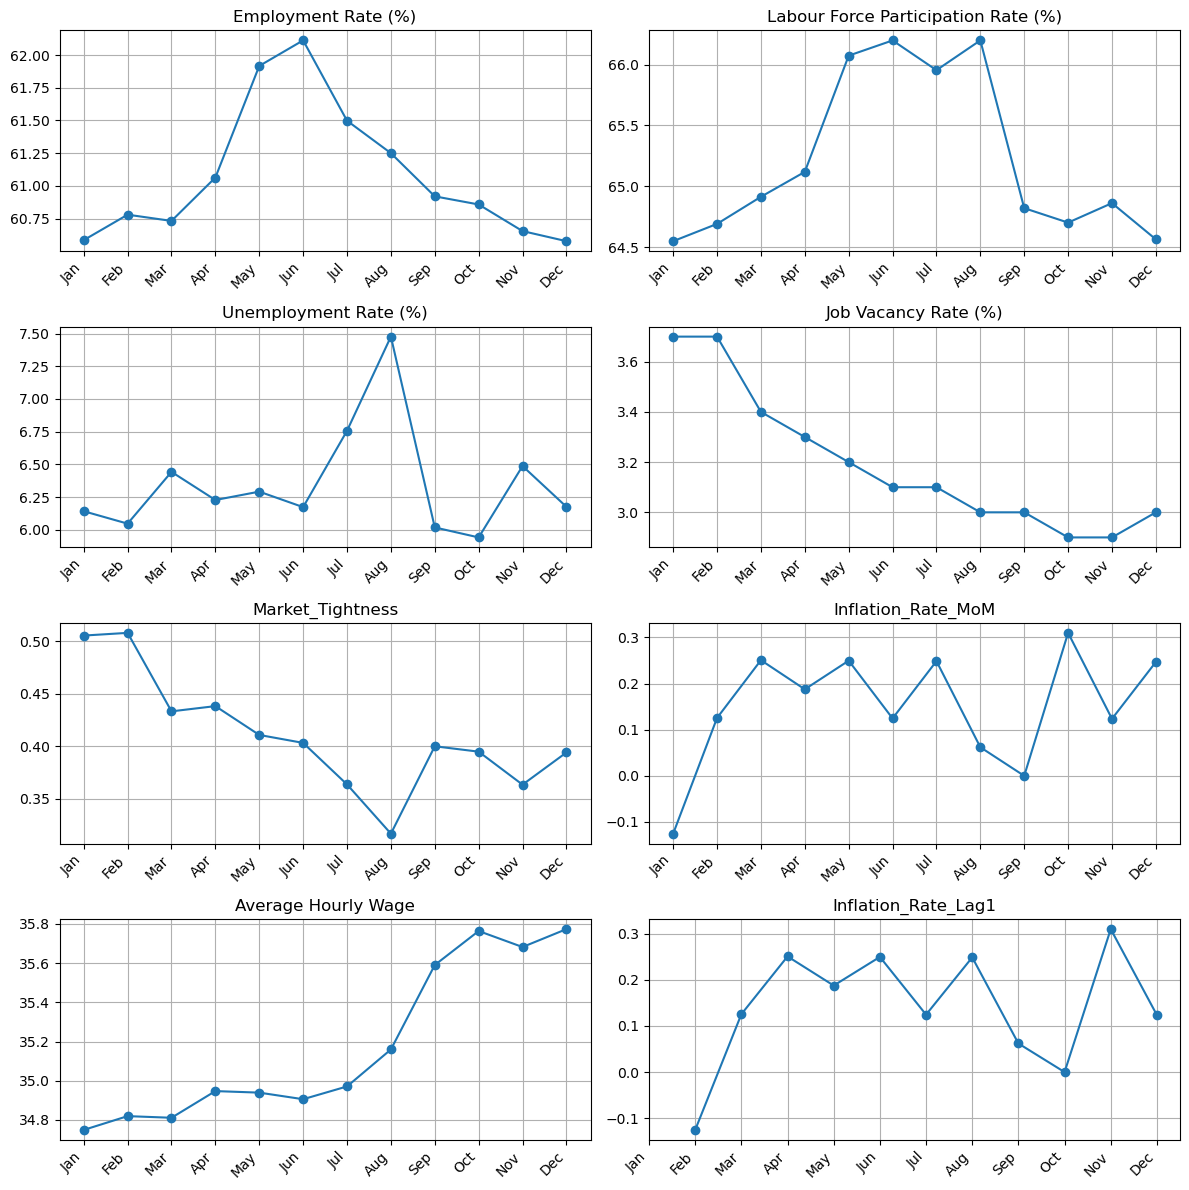

In [18]:
# List of indicators to plot
indicators = ["Employment Rate (%)", "Labour Force Participation Rate (%)", "Unemployment Rate (%)", 
              "Job Vacancy Rate (%)", "Market_Tightness", "Inflation_Rate_MoM", "Average Hourly Wage", 'Inflation_Rate_Lag1']
num_plots = len(indicators)

# Define rows & columns
ncols = 2
nrows = int(np.ceil(num_plots / ncols))  # Ensure enough rows

# Create subplots
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 3 * nrows), sharex=False)

# Flatten axes array for easy iteration
axes = axes.flatten()

# Plot each indicator
for i, col in enumerate(indicators):
    axes[i].plot(overall_indicators["Month"], overall_indicators[col], marker='o', linestyle='-')
    axes[i].set_title(col)
    axes[i].grid(True)

    # Force x-axis tick labels for every subplot
    axes[i].set_xticks(overall_indicators["Month"])  
    axes[i].set_xticklabels(overall_indicators["Month"], rotation=45, ha="right")  # Rotate for readability

# Remove any empty subplots if num_plots is odd
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()
plt.show()

Calculating correlation & partial correlation coefficients. 

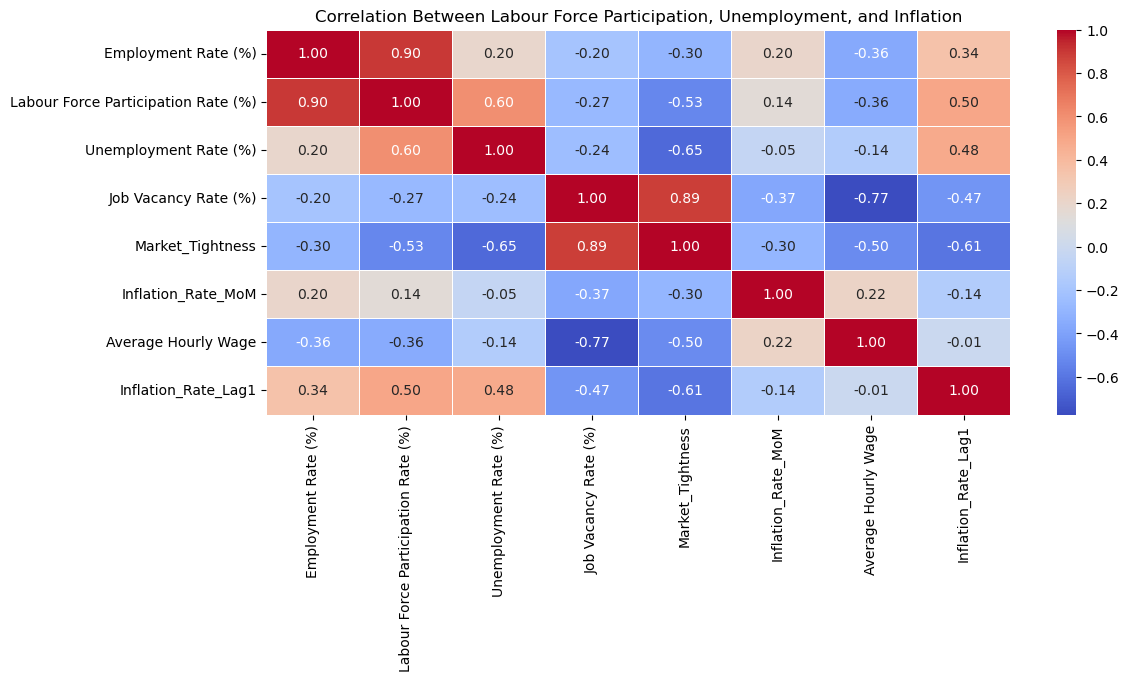

In [19]:
# Compute correlation
plt.figure(figsize=(12, 5))
sns.heatmap(overall_indicators[indicators].corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Between Labour Force Participation, Unemployment, and Inflation")
plt.show()



Correlation Matrix Interpretation

[1] Strong Positive Correlations
- Employment Rate (%) & Labour Force Participation Rate (%) (0.90): Higher participation in the labor force is strongly associated with higher employment rates.
- Job Vacancy Rate (%) & Market Tightness (0.89): A tight labor market (low unemployment, high demand for workers) naturally corresponds with more job vacancies.
- Unemployment Rate (%) & Labour Force Participation Rate (%) (0.60): When more people enter the workforce, the unemployment rate also rises, likely due to new entrants taking time to secure jobs.
- Inflation_Rate_Lag1 & Labour Force Participation Rate (%) (0.50): A lagged effect suggests that inflation from previous months correlates with increased labor force participation.
- Inflation_Rate_Lag1 & Unemployment Rate (%) (0.48): Higher inflation from the past months may be linked to rising unemployment, possibly due to cost pressures on businesses.

[2] Strong Negative Correlations
- Market Tightness & Unemployment Rate (%) (-0.65): When unemployment is high, market tightness is low (fewer job openings per unemployed person), and vice versa.
- Job Vacancy Rate (%) & Average Hourly Wage (-0.77): More job vacancies seem to be associated with lower wages, possibly reflecting demand for lower-paid roles.
- Market Tightness & Average Hourly Wage (-0.50): A tighter job market (more vacancies per unemployed worker) is linked to lower wages, which could indicate employers hiring at lower pay levels.
- Market Tightness & Labour Force Participation Rate (%) (-0.53): A higher market tightness (more vacancies per unemployed worker) could indicate a lower labor force participation rate, as more people may be discouraged from entering the workforce due to fewer available job opportunities.
- Job Vacancy Rate (%) & Inflation_Rate_Lag1 (-0.47): More job vacancies can lead to lower inflation in the short term, perhaps due to the increased supply of workers reducing wage pressures.

[3] Moderate Positive Correlations
- Employment Rate (%) & Inflation_Rate_Lag1 (0.34):When employment rates rise, there is a moderate correlation with inflation from the previous months, suggesting a lagged response between increased employment and inflation.

[4] Moderate Negative Correlations
- Market Tightness & Employment Rate (%) (-0.30): A tighter labor market (with fewer unemployed workers per job opening) is moderately negatively correlated with the employment rate, suggesting that a lack of workers may hinder new hires despite an otherwise healthy job market.
- Employment Rate (%) & Average Hourly Wage (-0.36): As the employment rate increases, wages tend to moderate, potentially reflecting greater workforce supply and less upward pressure on wages.
- Labour Force Participation Rate (%) & Average Hourly Wage (-0.36): A higher labor force participation rate could coincide with lower average hourly wages, possibly because of more people entering the workforce at lower pay levels.
- Job Vacancy Rate (%) & Inflation_Rate_MoM (-0.37): More job vacancies may be moderately correlated with a decrease in month-over-month inflation, possibly reflecting a temporary labor supply surplus leading to wage stabilization.
- Market Tightness & Inflation_Rate_MoM (-0.30): A moderate negative relationship suggests that a tighter labor market may coincide with lower inflation month-over-month, potentially due to reduced wage growth and lower demand pressures.

In [20]:
import itertools

# Dataframe with these indicators
df = overall_indicators[indicators]

# Initialize an empty list to store the results
results = []

# Get all combinations of indicator pairs
combinations = list(itertools.combinations(indicators, 2))

# Loop through each combination
for var1, var2 in combinations:
    # Control for all other variables except var1 and var2
    controls = [var for var in indicators if var != var1 and var != var2]
    
    # Calculate partial correlation
    result = pg.partial_corr(data=df, x=var1, y=var2, covar=controls)
    
    # Store the results
    results.append({
        'Var1': var1,
        'Var2': var2,
        'Partial Correlation': result.iloc[0]['r'],  # Use iloc to access by position
        'p-val': result.iloc[0]['p-val'],  # Use iloc to access by position
        'CI95%': result.iloc[0]['CI95%']  # Use iloc to access by position
    })

# Convert results into a DataFrame
results_df = pd.DataFrame(results)

# Filter the DataFrame to only include rows with p-value < 0.05
significant_results = results_df[results_df['p-val'] < 0.05]

# Print the filtered results
print(significant_results)


                                   Var1                                 Var2  Partial Correlation  p-val          CI95%
0                   Employment Rate (%)  Labour Force Participation Rate (%)                1.000  0.000     [1.0, 1.0]
1                   Employment Rate (%)                Unemployment Rate (%)               -1.000  0.000  [-1.0, -0.99]
7   Labour Force Participation Rate (%)                Unemployment Rate (%)                1.000  0.000    [0.99, 1.0]
17                Unemployment Rate (%)                  Inflation_Rate_Lag1                0.884  0.047   [0.01, 0.99]
18                 Job Vacancy Rate (%)                     Market_Tightness                0.982  0.003    [0.75, 1.0]


1. Employment Rate (%) vs. Labour Force Participation Rate (%)

Partial Correlation: 1.000
p-val: 0.000 (This is statistically significant)
CI95%: [1.0, 1.0]
Interpretation: The partial correlation of 1.000 means a perfect positive relationship between the Employment Rate and the Labour Force Participation Rate after controlling for other variables. This suggests that as the employment rate increases, the labour force participation rate increases in a perfectly linear way. The p-value of 0.000 shows that this result is statistically significant.

2. Employment Rate (%) vs. Unemployment Rate (%)

Partial Correlation: -1.000
p-val: 0.000 (Statistically significant)
CI95%: [-1.0, -0.99]
Interpretation: A perfect negative correlation of -1.000 indicates that the Employment Rate and the Unemployment Rate are inversely related after controlling for other variables. When the employment rate increases, the unemployment rate decreases (and vice versa). This result is statistically significant with a p-value of 0.000.

3. Labour Force Participation Rate (%) vs. Unemployment Rate (%)

Partial Correlation: 1.000
p-val: 0.000 (Statistically significant)
CI95%: [0.99, 1.0]
Interpretation: Similar to the first case, the perfect positive correlation of 1.000 between the Labour Force Participation Rate and the Unemployment Rate means that as the labour force participation rate increases, the unemployment rate increases as well. This result is statistically significant (p-value 0.000).

4. Unemployment Rate (%) vs. Inflation Rate Lag1

Partial Correlation: 0.884
p-val: 0.047 (Statistically significant)
CI95%: [0.01, 0.99]
Interpretation: A 0.884 partial correlation suggests a strong positive relationship between the Unemployment Rate and Inflation Rate (Lag1) after controlling for other variables. This means that as the unemployment rate increases, the inflation rate also tends to increase. The p-value of 0.047 shows that this relationship is statistically significant at the 5% level.

5. Job Vacancy Rate (%) vs. Market Tightness

Partial Correlation: 0.982
p-val: 0.003 (Statistically significant)
CI95%: [0.75, 1.0]
Interpretation: The partial correlation of 0.982 indicates a very strong positive relationship between the Job Vacancy Rate and Market Tightness, suggesting that as job vacancies increase, market tightness also increases. This result is statistically significant with a p-value of 0.003.

Moving Forward
- To avoid multicollinearity in the machine learning models due to Labour Force Participation Rate (%) high collinearity with Unemployment Rate (%) & Employment Rate (%), only Unemployment Rate (%) will be used.
- To avoid multicollinearity in the machine learning models due to Job Vacancy Rate (%) high collinearity with Market Tightness, only Market Tightness will be used.


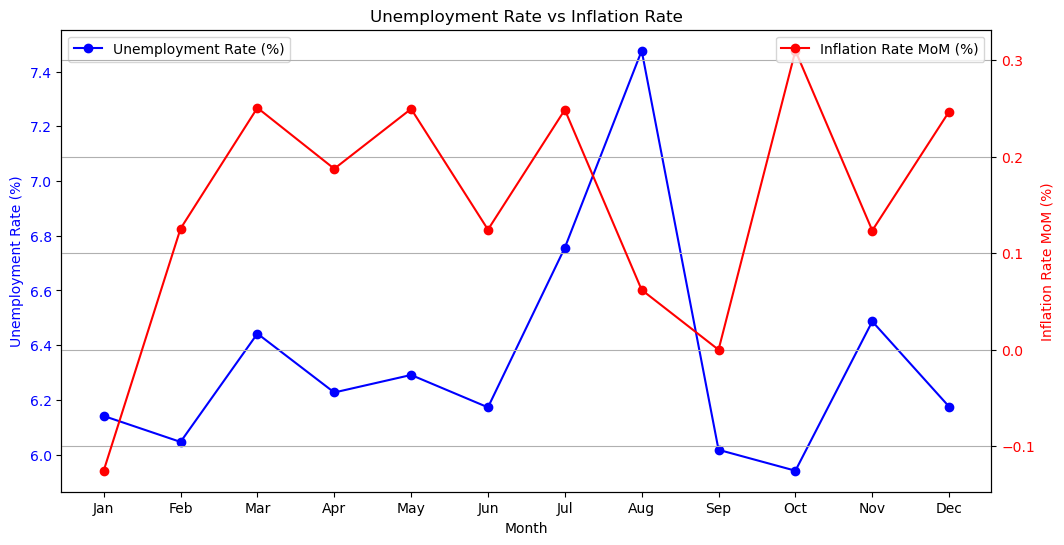

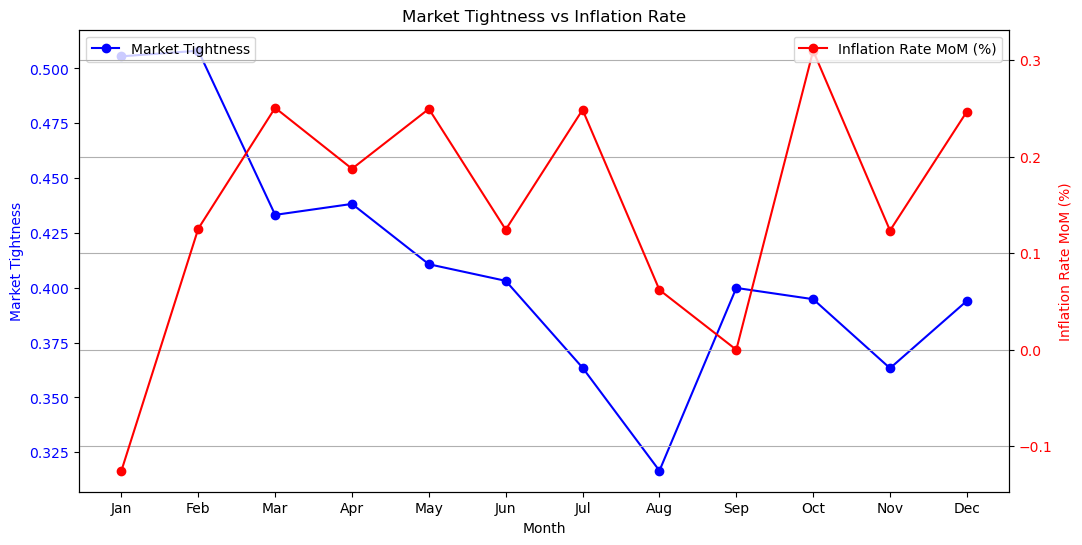

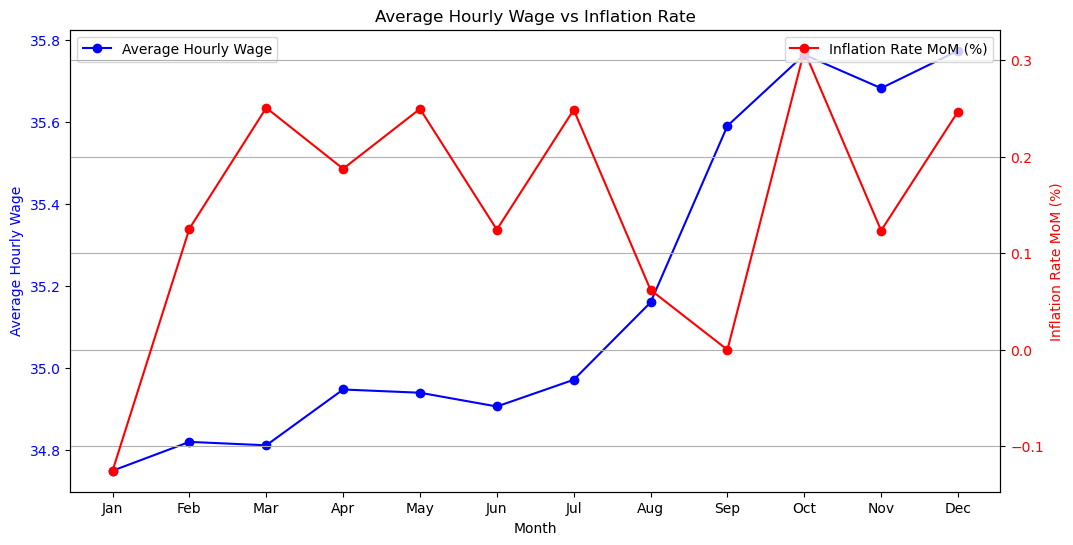

In [21]:
# Plot 1: Unemployment Rate vs Inflation Rate
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary y-axis for Unemployment Rate
ax1.set_xlabel('Month')
ax1.set_ylabel('Unemployment Rate (%)', color='blue')
ax1.plot(overall_indicators['Month'], overall_indicators['Unemployment Rate (%)'], label='Unemployment Rate (%)', marker="o", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Secondary y-axis for Inflation Rate
ax2 = ax1.twinx()
ax2.set_ylabel('Inflation Rate MoM (%)', color='red')
ax2.plot(overall_indicators['Month'], overall_indicators['Inflation_Rate_MoM'], label="Inflation Rate MoM (%)", marker="o", color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Title and formatting
plt.title("Unemployment Rate vs Inflation Rate")
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.grid()
plt.xticks(rotation=45)
plt.show()

# Plot 2: Market Tightness vs Inflation Rate
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary y-axis for Market Tightness
ax1.set_xlabel('Month')
ax1.set_ylabel('Market Tightness', color='blue')
ax1.plot(overall_indicators['Month'], overall_indicators['Market_Tightness'], label='Market Tightness', marker="o", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Secondary y-axis for Inflation Rate
ax2 = ax1.twinx()
ax2.set_ylabel('Inflation Rate MoM (%)', color='red')
ax2.plot(overall_indicators['Month'], overall_indicators['Inflation_Rate_MoM'], label="Inflation Rate MoM (%)", marker="o", color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Title and formatting
plt.title("Market Tightness vs Inflation Rate")
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.grid()
plt.xticks(rotation=45)
plt.show()

# Plot 3: Average Hourly Wage vs Inflation Rate
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary y-axis for Average Hourly Wage
ax1.set_xlabel('Month')
ax1.set_ylabel('Average Hourly Wage', color='blue')
ax1.plot(overall_indicators['Month'], overall_indicators['Average Hourly Wage'], label='Average Hourly Wage', marker="o", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Secondary y-axis for Inflation Rate
ax2 = ax1.twinx()
ax2.set_ylabel('Inflation Rate MoM (%)', color='red')
ax2.plot(overall_indicators['Month'], overall_indicators['Inflation_Rate_MoM'], label="Inflation Rate MoM (%)", marker="o", color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Title and formatting
plt.title("Average Hourly Wage vs Inflation Rate")
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.grid()
plt.xticks(rotation=45)
plt.show()


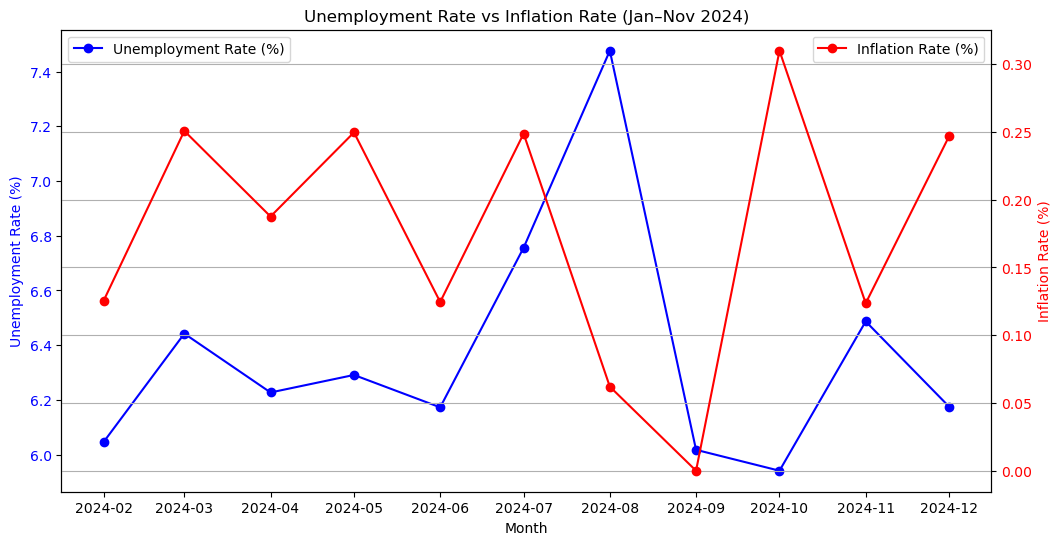

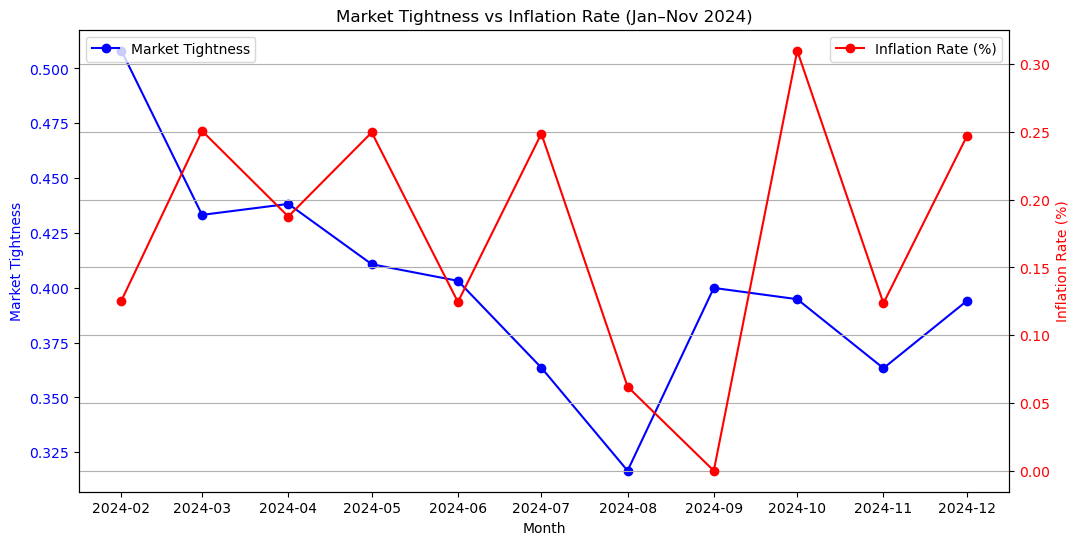

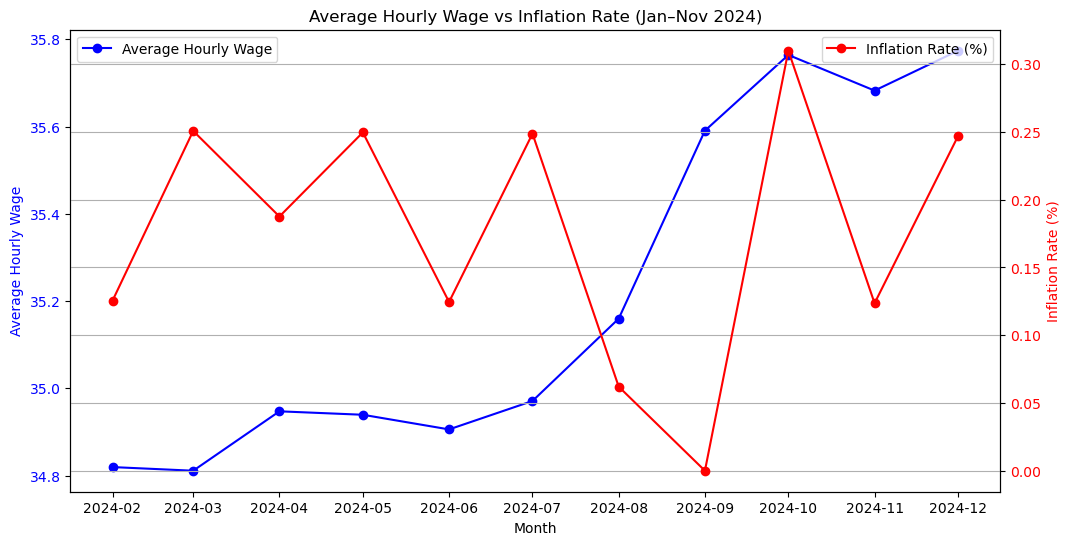

In [22]:
import matplotlib.pyplot as plt

# Drop rows where 'Inflation_Rate_Lag1' is NaN
overall_indicators_clean = overall_indicators.dropna(subset=['Inflation_Rate_Lag1'])

# Plot 1: Unemployment Rate vs Inflation Rate
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary y-axis for Unemployment Rate
ax1.set_xlabel('Month')
ax1.set_ylabel('Unemployment Rate (%)', color='blue')
ax1.plot(overall_indicators_clean['REF_DATE'], overall_indicators_clean['Unemployment Rate (%)'], label='Unemployment Rate (%)', marker="o", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Secondary y-axis for Inflation Rate
ax2 = ax1.twinx()
ax2.set_ylabel('Inflation Rate (%)', color='red')
ax2.plot(overall_indicators_clean['REF_DATE'], overall_indicators_clean['Inflation_Rate_MoM'], label="Inflation Rate (%)", marker="o", color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Title and formatting
plt.title("Unemployment Rate vs Inflation Rate (Jan–Nov 2024)")
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.grid()
plt.xticks(rotation=45)
plt.show()

# Plot 2: Market Tightness vs Inflation Rate
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary y-axis for Market Tightness
ax1.set_xlabel('Month')
ax1.set_ylabel('Market Tightness', color='blue')
ax1.plot(overall_indicators_clean['REF_DATE'], overall_indicators_clean['Market_Tightness'], label='Market Tightness', marker="o", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Secondary y-axis for Inflation Rate
ax2 = ax1.twinx()
ax2.set_ylabel('Inflation Rate (%)', color='red')
ax2.plot(overall_indicators_clean['REF_DATE'], overall_indicators_clean['Inflation_Rate_MoM'], label="Inflation Rate (%)", marker="o", color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Title and formatting
plt.title("Market Tightness vs Inflation Rate (Jan–Nov 2024)")
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.grid()
plt.xticks(rotation=45)
plt.show()

# Plot 3: Average Hourly Wage vs Inflation Rate
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary y-axis for Average Hourly Wage
ax1.set_xlabel('Month')
ax1.set_ylabel('Average Hourly Wage', color='blue')
ax1.plot(overall_indicators_clean['REF_DATE'], overall_indicators_clean['Average Hourly Wage'], label='Average Hourly Wage', marker="o", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Secondary y-axis for Inflation Rate
ax2 = ax1.twinx()
ax2.set_ylabel('Inflation Rate (%)', color='red')
ax2.plot(overall_indicators_clean['REF_DATE'], overall_indicators_clean['Inflation_Rate_MoM'], label="Inflation Rate (%)", marker="o", color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Title and formatting
plt.title("Average Hourly Wage vs Inflation Rate (Jan–Nov 2024)")
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.grid()
plt.xticks(rotation=45)
plt.show()


## Overal trends between industries: unemployment, labour market tightness, avg duration unemployed, avg duration jobless, average wage 

In [23]:
industry_trends = pd.read_csv('Data/Monthly Industry Labour Market Rates.csv')
industry_trends['REF_DATE'] = pd.to_datetime(industry_trends['REF_DATE'])
industry_trends['Month'] = industry_trends['REF_DATE'].dt.strftime('%b')
industry_trends.head()


,Unnamed: 0,REF_DATE,NAICS_21,employment_rate,unemployment_rate,Job Vacancies (#),Payroll Employees (#),Job Vacancy Rate (%),All-items,Inflation_Rate_MoM,Market_Tightness,Average Hourly Wage,Month
0,0,2024-01-01,1.000,95.840,4.160,6773.000,185551.000,3.500,159.300,-0.125,0.731,23.722,Jan
1,1,2024-01-01,2.000,87.430,12.570,1339.000,36697.000,3.500,159.300,-0.125,0.242,34.019,Jan
2,2,2024-01-01,3.000,61.730,38.270,628.000,17207.000,3.500,159.300,-0.125,0.079,30.671,Jan
3,3,2024-01-01,4.000,93.170,6.830,5650.000,208720.000,2.600,159.300,-0.125,0.281,49.631,Jan
4,4,2024-01-01,5.000,98.510,1.490,3075.000,134150.000,2.200,159.300,-0.125,1.338,50.538,Jan


In [24]:
import pandas as pd

# Grouping by month and industry, then averaging the unemployment duration
avg_unemployment_duration = LFS.groupby(['REF_DATE', 'NAICS_21'])['duration_unemp'].mean().reset_index()
avg_unemployment_duration['REF_DATE'] = pd.to_datetime(avg_unemployment_duration['REF_DATE'])
avg_joblessness_duration = LFS.groupby(['REF_DATE', 'NAICS_21'])['duration_jobless'].mean().reset_index()
avg_joblessness_duration['REF_DATE'] = pd.to_datetime(avg_joblessness_duration['REF_DATE'])


# Merge both datasets on REF_DATE and NAICS_21
industry_trends = industry_trends \
    .merge(avg_unemployment_duration, on=['REF_DATE', 'NAICS_21'], how='left') \
    .merge(avg_joblessness_duration, on=['REF_DATE', 'NAICS_21'], how='left')

# Optional: Fill NaN values if needed
industry_trends.fillna(0, inplace=True)  # Replace NaN with 0

# Display result
print(industry_trends.head())



   Unnamed: 0   REF_DATE NAICS_21  employment_rate  unemployment_rate  Job Vacancies (#)  Payroll Employees (#)  Job Vacancy Rate (%)  All-items  Inflation_Rate_MoM  Market_Tightness  Average Hourly Wage Month  duration_unemp  duration_jobless
0           0 2024-01-01    1.000           95.840              4.160           6773.000             185551.000                 3.500    159.300              -0.125             0.731               23.722   Jan           9.286             4.670
1           1 2024-01-01    2.000           87.430             12.570           1339.000              36697.000                 3.500    159.300              -0.125             0.242               34.019   Jan          12.630             4.518
2           2 2024-01-01    3.000           61.730             38.270            628.000              17207.000                 3.500    159.300              -0.125             0.079               30.671   Jan          14.892             5.629
3           3 2024-01-01

/var/folders/n9/29yl9jnj61q74vg3ydjdf3qh0000gn/T/ipykernel_27917/31296335.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_unemployment_duration = LFS.groupby(['REF_DATE', 'NAICS_21'])['duration_unemp'].mean().reset_index()
/var/folders/n9/29yl9jnj61q74vg3ydjdf3qh0000gn/T/ipykernel_27917/31296335.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_joblessness_duration = LFS.groupby(['REF_DATE', 'NAICS_21'])['duration_jobless'].mean().reset_index()


In [25]:
industry_trends.tail()

,Unnamed: 0,REF_DATE,NAICS_21,employment_rate,unemployment_rate,Job Vacancies (#),Payroll Employees (#),Job Vacancy Rate (%),All-items,Inflation_Rate_MoM,Market_Tightness,Average Hourly Wage,Month,duration_unemp,duration_jobless
247,247,2024-12-01,17.000,98.560,1.440,107290.000,2420560.000,4.200,162.400,0.247,2.575,33.996,Dec,12.352,5.909
248,248,2024-12-01,18.000,92.440,7.560,16305.000,678580.000,2.342,162.400,0.247,0.245,32.138,Dec,9.627,4.665
249,249,2024-12-01,19.000,94.170,5.830,61490.000,1297490.000,4.500,162.400,0.247,0.851,20.356,Dec,11.844,5.225
250,250,2024-12-01,20.000,96.150,3.850,25275.000,569490.000,4.200,162.400,0.247,0.813,30.942,Dec,12.000,5.610
251,251,2024-12-01,21.000,98.320,1.680,13555.000,577470.000,2.300,162.400,0.247,0.661,44.752,Dec,10.690,5.302


/var/folders/n9/29yl9jnj61q74vg3ydjdf3qh0000gn/T/ipykernel_27917/700519554.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  industry_wages_avg = industry_trends.groupby('NAICS_21')['Average Hourly Wage'].mean().reset_index()
/var/folders/n9/29yl9jnj61q74vg3ydjdf3qh0000gn/T/ipykernel_27917/700519554.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


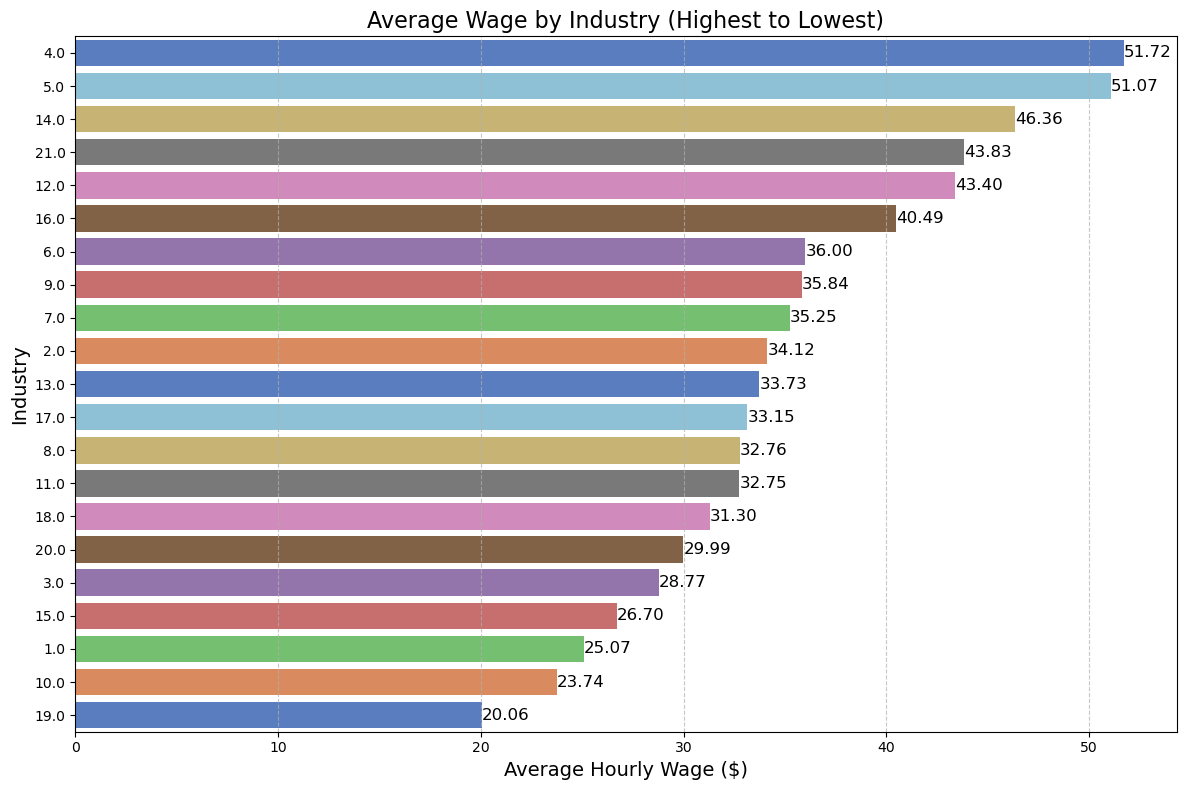

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming industry_trends is your DataFrame
# Convert NAICS_21 to a categorical type
industry_trends['NAICS_21'] = industry_trends['NAICS_21'].astype('category')

# Calculate the average hourly wage for each industry across all 12 months
industry_wages_avg = industry_trends.groupby('NAICS_21')['Average Hourly Wage'].mean().reset_index()

# Sort the average hourly wages in descending order
industry_wages_sorted = industry_wages_avg.sort_values("Average Hourly Wage", ascending=True)

# Create a larger figure for better visualization
plt.figure(figsize=(12, 8))

# Create the horizontal bar chart using Seaborn's barplot
sns.barplot(
    data=industry_wages_sorted,
    y="NAICS_21",
    x="Average Hourly Wage",
    palette="muted",  # You can choose any palette you like
    orient='h',  # Horizontal orientation
    order=industry_wages_sorted['NAICS_21']  # Set the order based on sorted wages
)

# Add labels and title
plt.xlabel("Average Hourly Wage ($)", fontsize=14)
plt.ylabel("Industry", fontsize=14)
plt.title("Average Wage by Industry (Highest to Lowest)", fontsize=16)

# Add a grid for better readability
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add value labels to each bar
for index, value in enumerate(industry_wages_sorted['Average Hourly Wage']):
    plt.text(value, index, f'{value:,.2f}', va='center', ha='left', fontsize=12, color='black')

# Invert the y-axis to have the highest wage at the top
plt.gca().invert_yaxis()

# Show the plot
plt.tight_layout()  # Adjust layout to prevent clipping
plt.show()

/var/folders/n9/29yl9jnj61q74vg3ydjdf3qh0000gn/T/ipykernel_27917/251093349.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  industry_unemp_avg = industry_trends.groupby('NAICS_21')['duration_unemp'].mean().reset_index()
/var/folders/n9/29yl9jnj61q74vg3ydjdf3qh0000gn/T/ipykernel_27917/251093349.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


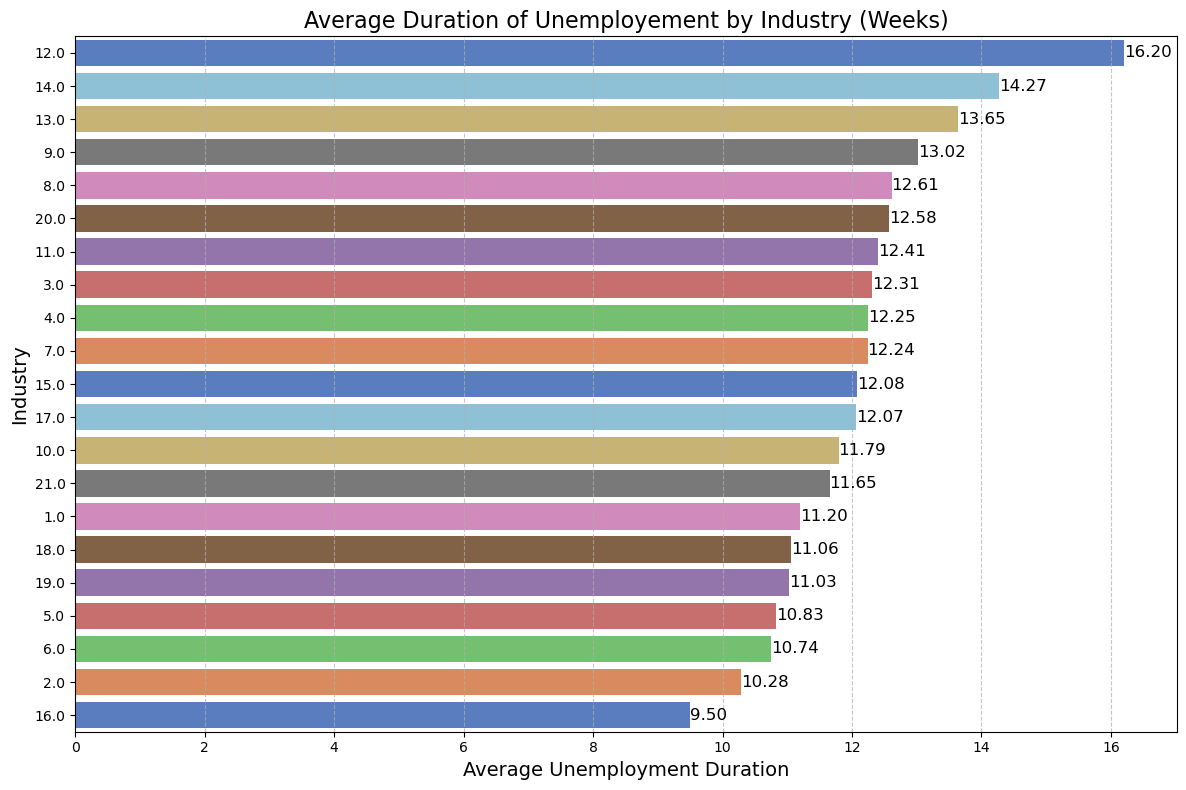

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Calculate the average duration of unemployment wage for each industry across all 12 months
industry_unemp_avg = industry_trends.groupby('NAICS_21')['duration_unemp'].mean().reset_index()

# Sort the average hourly wages in descending order
industry_unemp_sorted = industry_unemp_avg.sort_values("duration_unemp", ascending=True)

# Create a larger figure for better visualization
plt.figure(figsize=(12, 8))

# Create the horizontal bar chart using Seaborn's barplot
sns.barplot(
    data=industry_unemp_sorted,
    y="NAICS_21",
    x="duration_unemp",
    palette="muted",  # You can choose any palette you like
    orient='h',  # Horizontal orientation
    order=industry_unemp_sorted['NAICS_21']  # Set the order based on sorted wages
)

# Add labels and title
plt.xlabel("Average Unemployment Duration", fontsize=14)
plt.ylabel("Industry", fontsize=14)
plt.title("Average Duration of Unemployement by Industry (Weeks)", fontsize=16)

# Add a grid for better readability
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add value labels to each bar
for index, value in enumerate(industry_unemp_sorted['duration_unemp']):
    plt.text(value, index, f'{value:,.2f}', va='center', ha='left', fontsize=12, color='black')

# Invert the y-axis to have the highest wage at the top
plt.gca().invert_yaxis()

# Show the plot
plt.tight_layout()  # Adjust layout to prevent clipping
plt.show()

/var/folders/n9/29yl9jnj61q74vg3ydjdf3qh0000gn/T/ipykernel_27917/2988547974.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  industry_jobless_avg = industry_trends.groupby('NAICS_21')['duration_jobless'].mean().reset_index()
/var/folders/n9/29yl9jnj61q74vg3ydjdf3qh0000gn/T/ipykernel_27917/2988547974.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


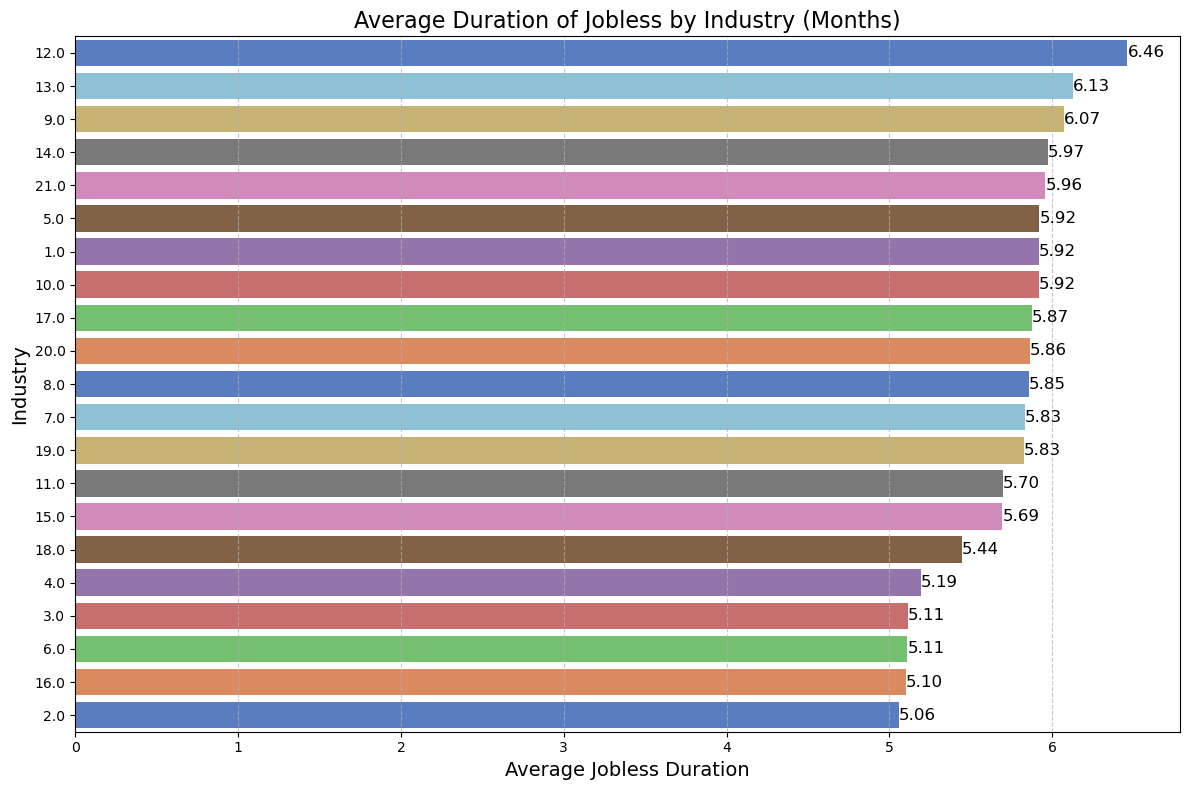

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Calculate the average duration of unemployment wage for each industry across all 12 months
industry_jobless_avg = industry_trends.groupby('NAICS_21')['duration_jobless'].mean().reset_index()

# Sort the average hourly wages in descending order
industry_jobless_sorted = industry_jobless_avg.sort_values("duration_jobless", ascending=True)

# Create a larger figure for better visualization
plt.figure(figsize=(12, 8))

# Create the horizontal bar chart using Seaborn's barplot
sns.barplot(
    data=industry_jobless_sorted,
    y="NAICS_21",
    x="duration_jobless",
    palette="muted",  # You can choose any palette you like
    orient='h',  # Horizontal orientation
    order=industry_jobless_sorted['NAICS_21']  # Set the order based on sorted wages
)

# Add labels and title
plt.xlabel("Average Jobless Duration", fontsize=14)
plt.ylabel("Industry", fontsize=14)
plt.title("Average Duration of Jobless by Industry (Months)", fontsize=16)

# Add a grid for better readability
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add value labels to each bar
for index, value in enumerate(industry_jobless_sorted['duration_jobless']):
    plt.text(value, index, f'{value:,.2f}', va='center', ha='left', fontsize=12, color='black')

# Invert the y-axis to have the highest wage at the top
plt.gca().invert_yaxis()

# Show the plot
plt.tight_layout()  # Adjust layout to prevent clipping
plt.show()

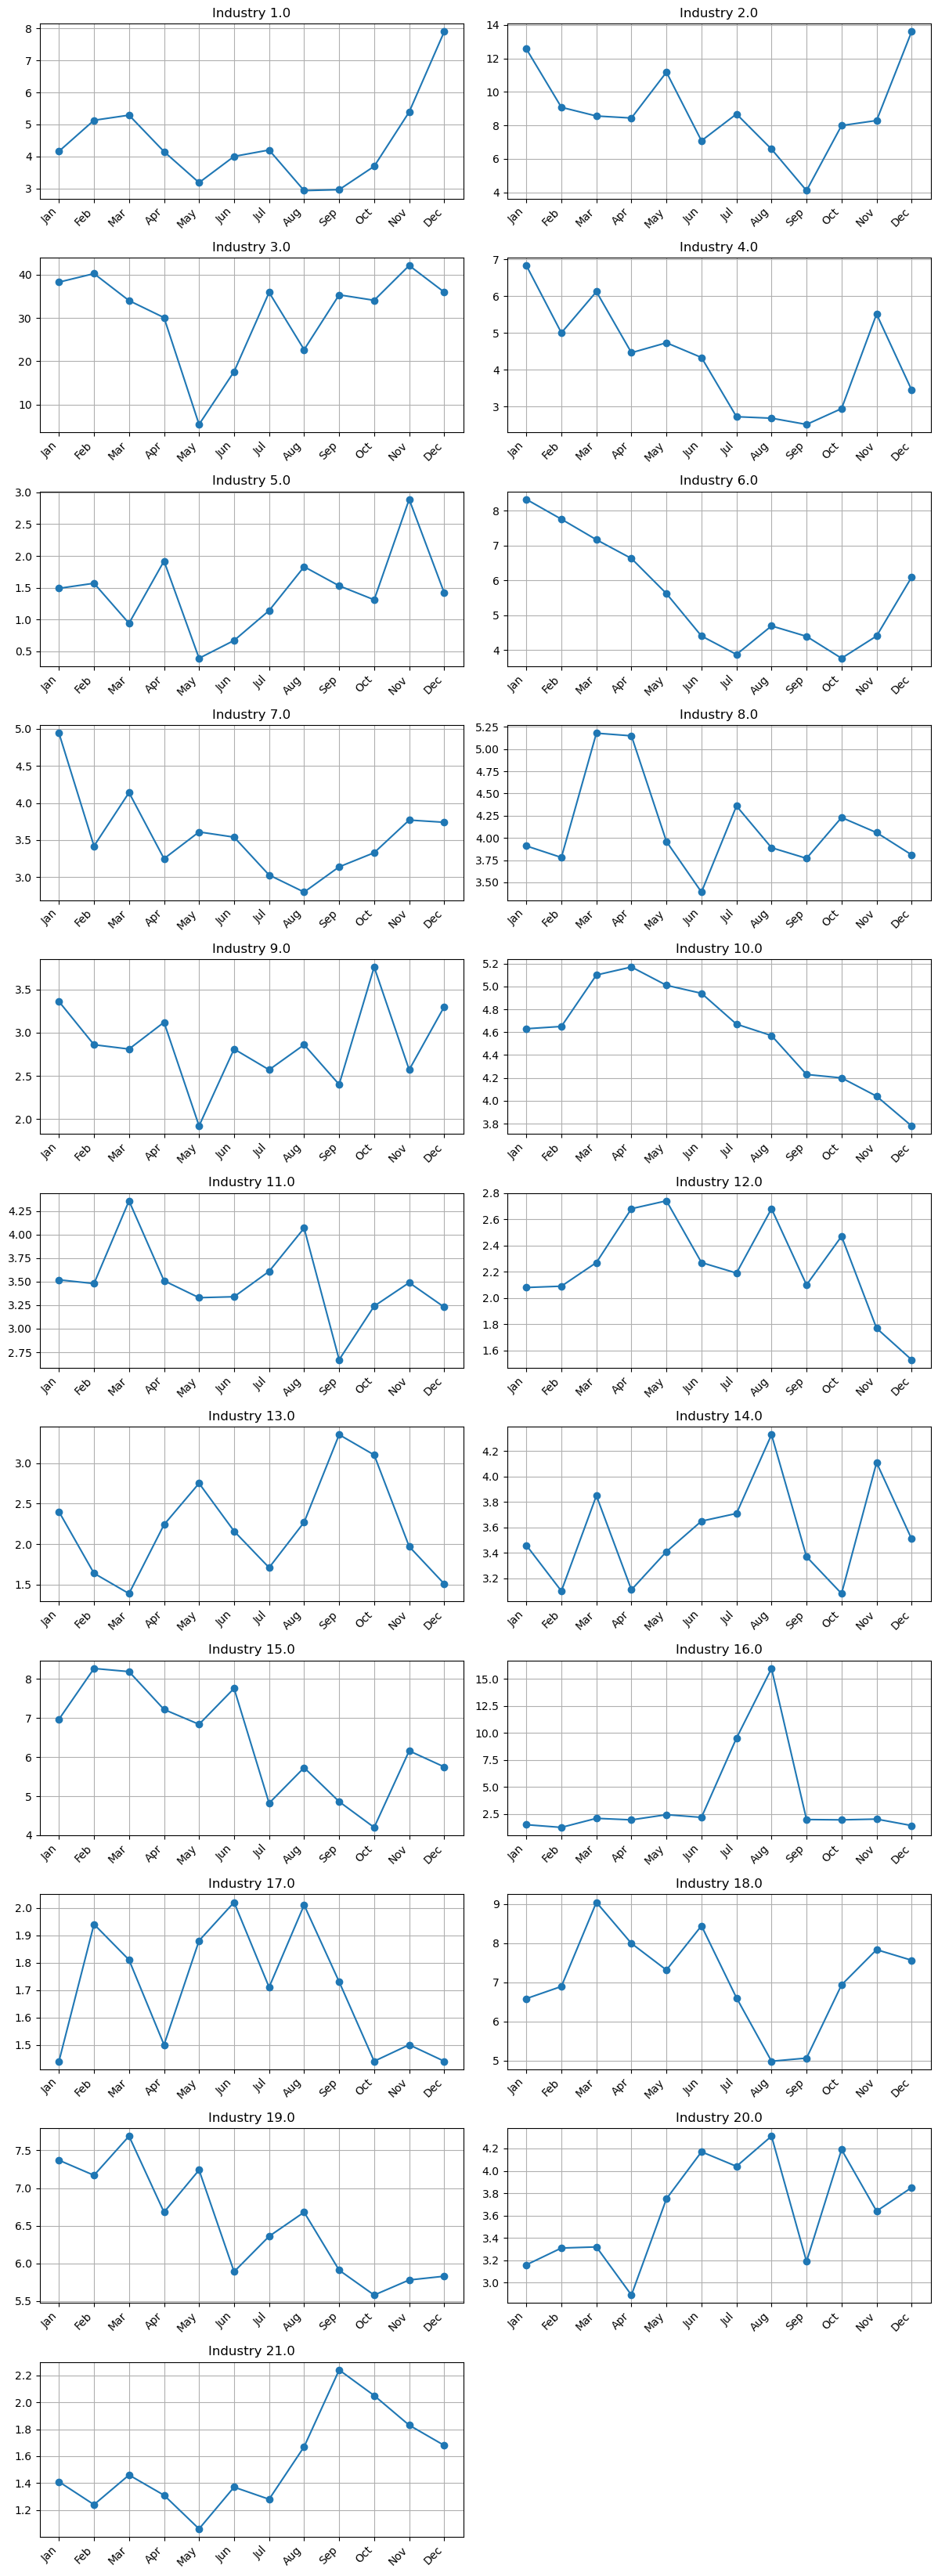

In [29]:
# List of industries to plot
industry_unemp_over_time = industry_trends['NAICS_21'].unique()
num_plots = len(industry_unemp_over_time)

# Define rows & columns
ncols = 2
nrows = int(np.ceil(num_plots / ncols))  # Ensure enough rows

# Create subplots
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 3 * nrows), sharex=False)

# Flatten axes array for easy iteration
axes = axes.flatten()

# Plot each industry
for i, industry in enumerate(industry_unemp_over_time):
    industry_data = industry_trends[industry_trends['NAICS_21'] == industry]
    axes[i].plot(industry_data["Month"], industry_data["unemployment_rate"], marker='o', linestyle='-')
    axes[i].set_title(f'Industry {industry}')
    axes[i].grid(True)

    # Force x-axis tick labels for every subplot
    axes[i].set_xticks(industry_data["Month"])  
    axes[i].set_xticklabels(industry_data["Month"], rotation=45, ha="right")  # Rotate for readability

# Remove any empty subplots if num_plots is odd
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()
plt.show()

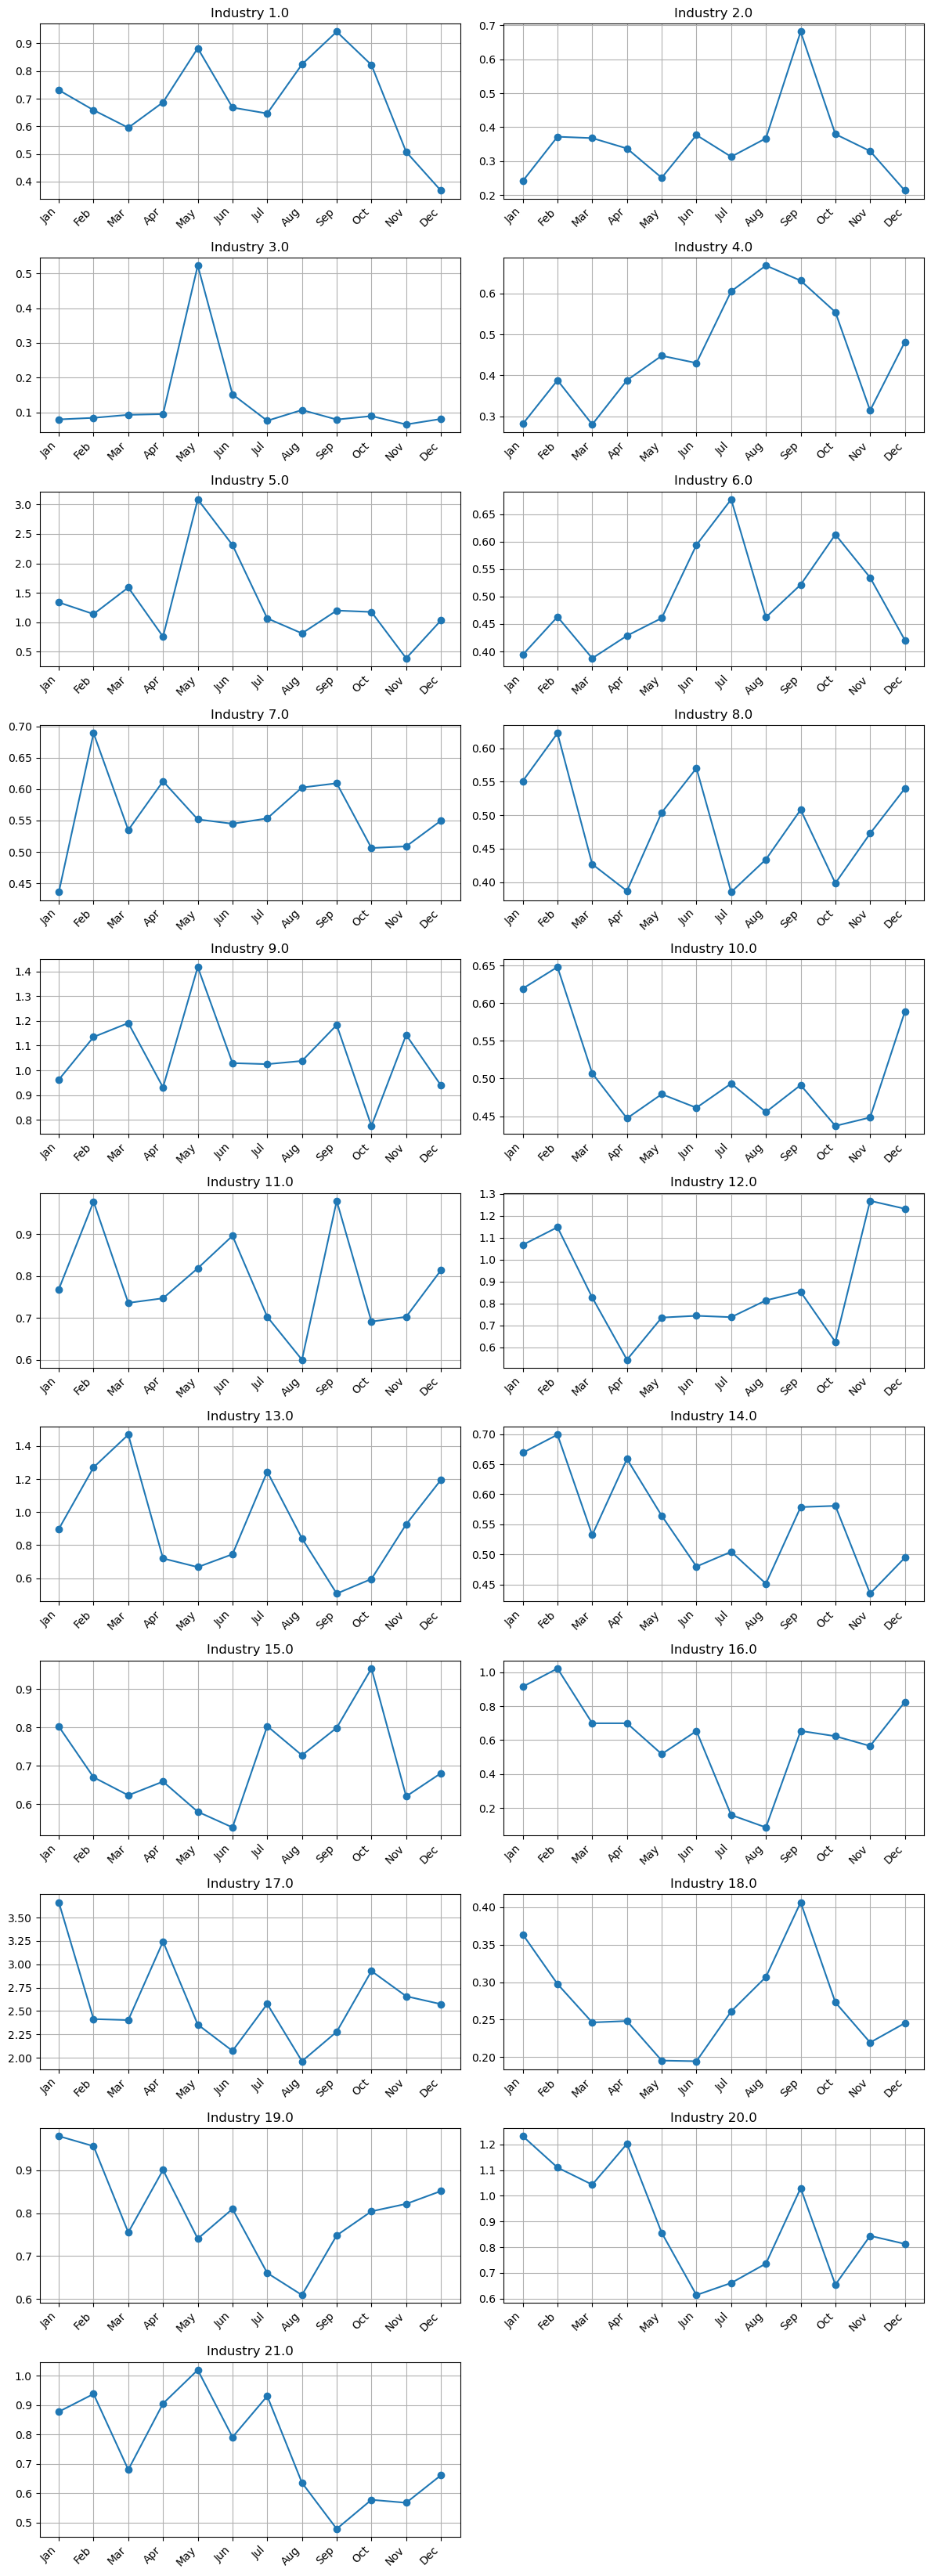

In [30]:
# List of industries to plot
industry_unemp_over_time = industry_trends['NAICS_21'].unique()
num_plots = len(industry_unemp_over_time)

# Define rows & columns
ncols = 2
nrows = int(np.ceil(num_plots / ncols))  # Ensure enough rows

# Create subplots
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 3 * nrows), sharex=False)

# Flatten axes array for easy iteration
axes = axes.flatten()

# Plot each industry
for i, industry in enumerate(industry_unemp_over_time):
    industry_data = industry_trends[industry_trends['NAICS_21'] == industry]
    axes[i].plot(industry_data["Month"], industry_data["Market_Tightness"], marker='o', linestyle='-')
    axes[i].set_title(f'Industry {industry}')
    axes[i].grid(True)

    # Force x-axis tick labels for every subplot
    axes[i].set_xticks(industry_data["Month"])  
    axes[i].set_xticklabels(industry_data["Month"], rotation=45, ha="right")  # Rotate for readability

# Remove any empty subplots if num_plots is odd
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()
plt.show()

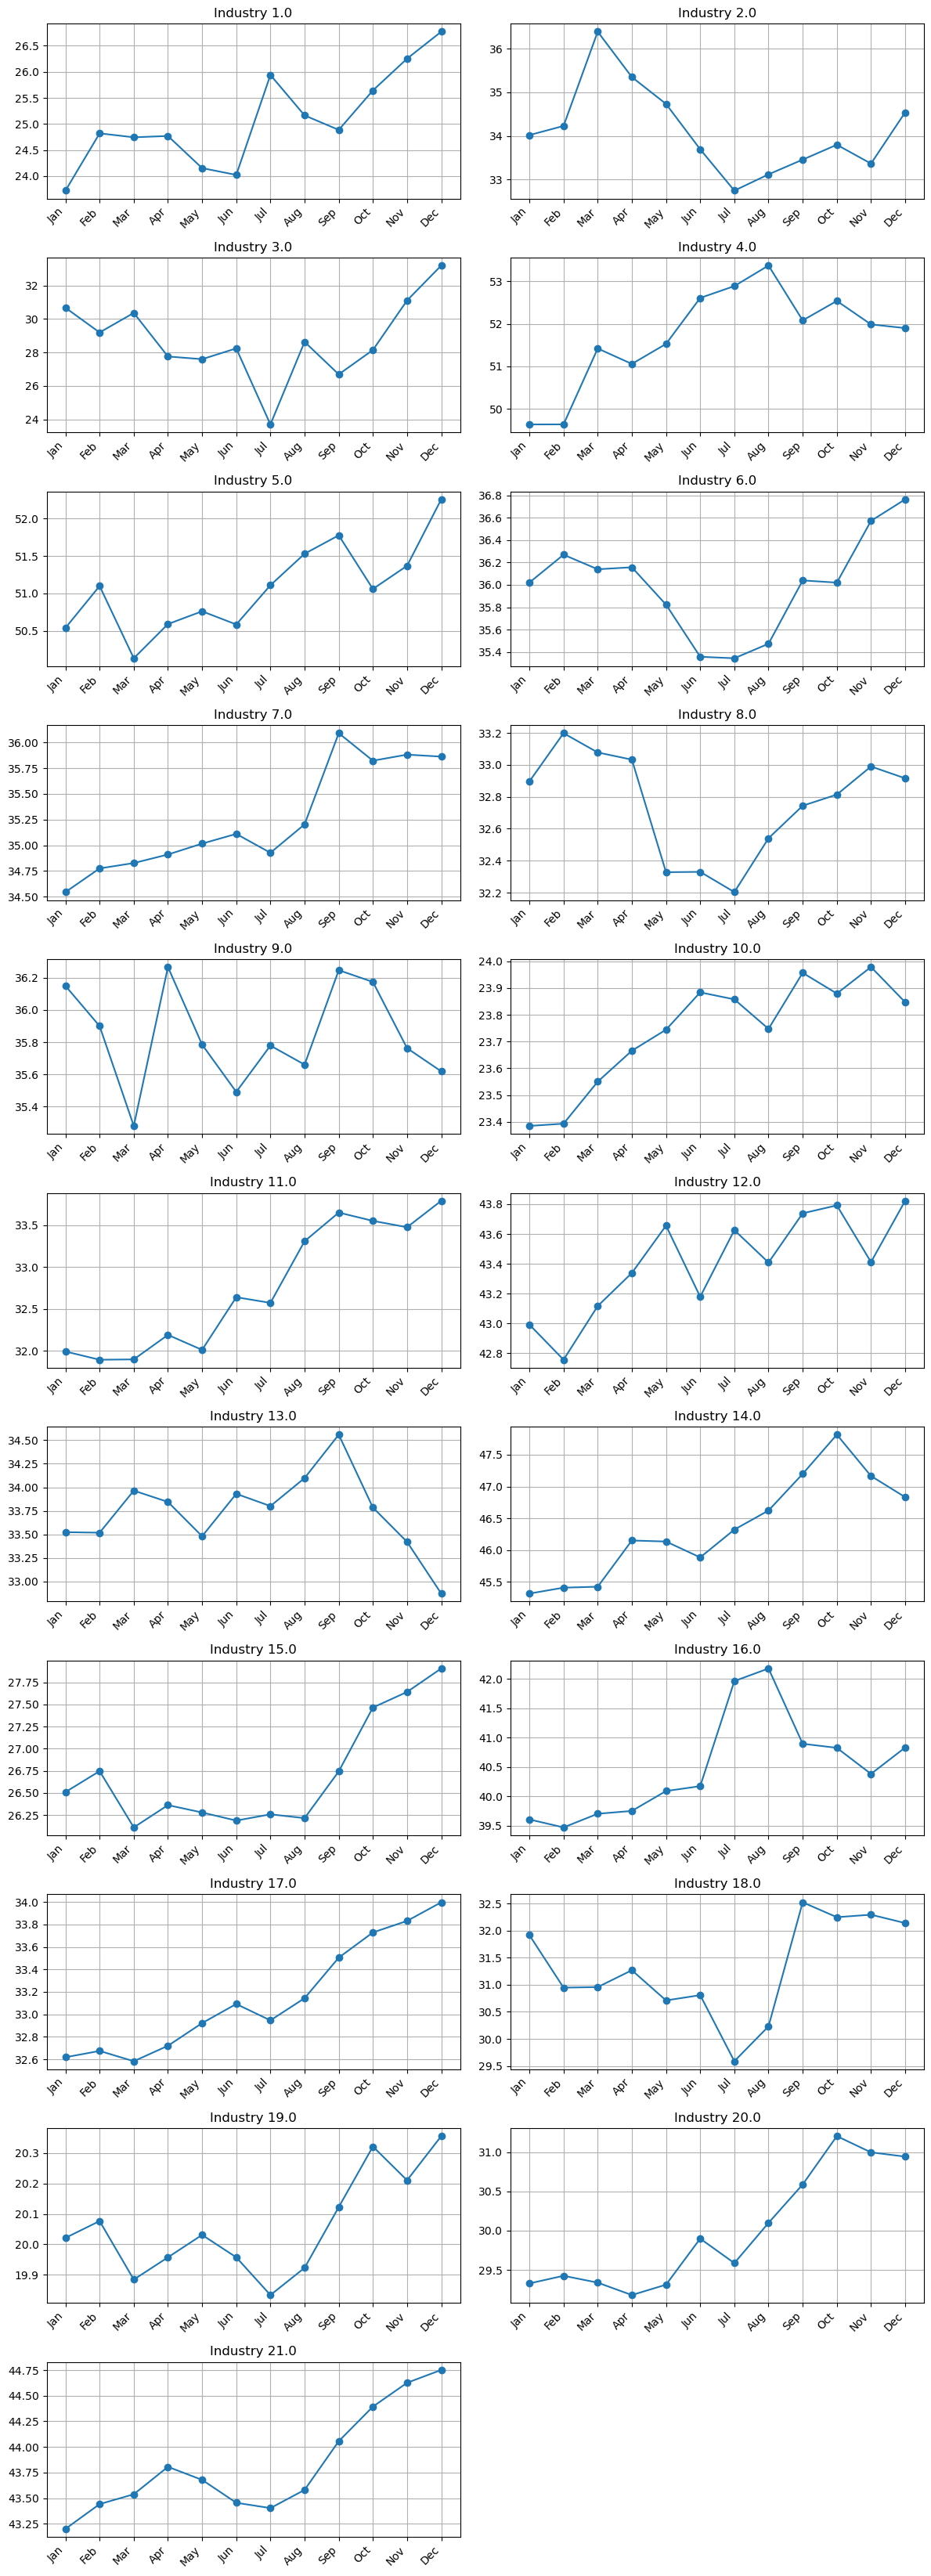

In [31]:
# List of industries to plot
industry_unemp_over_time = industry_trends['NAICS_21'].unique()
num_plots = len(industry_unemp_over_time)

# Define rows & columns
ncols = 2
nrows = int(np.ceil(num_plots / ncols))  # Ensure enough rows

# Create subplots
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 3 * nrows), sharex=False)

# Flatten axes array for easy iteration
axes = axes.flatten()

# Plot each industry
for i, industry in enumerate(industry_unemp_over_time):
    industry_data = industry_trends[industry_trends['NAICS_21'] == industry]
    axes[i].plot(industry_data["Month"], industry_data["Average Hourly Wage"], marker='o', linestyle='-')
    axes[i].set_title(f'Industry {industry}')
    axes[i].grid(True)

    # Force x-axis tick labels for every subplot
    axes[i].set_xticks(industry_data["Month"])  
    axes[i].set_xticklabels(industry_data["Month"], rotation=45, ha="right")  # Rotate for readability

# Remove any empty subplots if num_plots is odd
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()
plt.show()

In [32]:
import pandas as pd

# Assuming industry_trends is your DataFrame
industry_list = industry_trends['NAICS_21'].unique()  # Get list of unique industries

# Iterate over each industry
for industry in industry_list:
    industry_data = industry_trends[industry_trends['NAICS_21'] == industry]
    
    # Highest and lowest values and corresponding months for Unemployment Rate
    highest_unemp = industry_data.loc[industry_data['unemployment_rate'].idxmax()]
    lowest_unemp = industry_data.loc[industry_data['unemployment_rate'].idxmin()]
    
    # Highest and lowest values and corresponding months for Average Hourly Wage
    highest_wage = industry_data.loc[industry_data['Average Hourly Wage'].idxmax()]
    lowest_wage = industry_data.loc[industry_data['Average Hourly Wage'].idxmin()]
    
    # Highest and lowest values and corresponding months for Job Vacancy Rate
    highest_vacancy = industry_data.loc[industry_data['Job Vacancy Rate (%)'].idxmax()]
    lowest_vacancy = industry_data.loc[industry_data['Job Vacancy Rate (%)'].idxmin()]
    
    # Highest and lowest values and corresponding months for Market Tightness Ratio
    highest_tightness = industry_data.loc[industry_data['Market_Tightness'].idxmax()]
    lowest_tightness = industry_data.loc[industry_data['Market_Tightness'].idxmin()]
    
    # Highest and lowest values and corresponding months for Average Duration of Unemployment
    highest_unemp_duration = industry_data.loc[industry_data['duration_unemp'].idxmax()]
    lowest_unemp_duration = industry_data.loc[industry_data['duration_unemp'].idxmin()]
    
    # Highest and lowest values and corresponding months for Average Duration of Joblessness
    highest_joblessness_duration = industry_data.loc[industry_data['duration_jobless'].idxmax()]
    lowest_joblessness_duration = industry_data.loc[industry_data['duration_jobless'].idxmin()]

    # Output the results
    print(f"\nIndustry: {industry}")
    
    print(f"  Highest Unemployment Rate: {highest_unemp['unemployment_rate']} in {highest_unemp['Month']}")
    print(f"  Lowest Unemployment Rate: {lowest_unemp['unemployment_rate']} in {lowest_unemp['Month']}")
    
    print(f"  Highest Average Hourly Wage: {highest_wage['Average Hourly Wage']} in {highest_wage['Month']}")
    print(f"  Lowest Average Hourly Wage: {lowest_wage['Average Hourly Wage']} in {lowest_wage['Month']}")
    
    print(f"  Highest Job Vacancy Rate: {highest_vacancy['Job Vacancy Rate (%)']} in {highest_vacancy['Month']}")
    print(f"  Lowest Job Vacancy Rate: {lowest_vacancy['Job Vacancy Rate (%)']} in {lowest_vacancy['Month']}")
    
    print(f"  Highest Market Tightness Ratio: {highest_tightness['Market_Tightness']} in {highest_tightness['Month']}")
    print(f"  Lowest Market Tightness Ratio: {lowest_tightness['Market_Tightness']} in {lowest_tightness['Month']}")
    
    print(f"  Highest Average Duration of Unemployment: {highest_unemp_duration['duration_unemp']} in {highest_unemp_duration['Month']}")
    print(f"  Lowest Average Duration of Unemployment: {lowest_unemp_duration['duration_unemp']} in {lowest_unemp_duration['Month']}")
    
    print(f"  Highest Average Duration of Joblessness: {highest_joblessness_duration['duration_jobless']} in {highest_joblessness_duration['Month']}")
    print(f"  Lowest Average Duration of Joblessness: {lowest_joblessness_duration['duration_jobless']} in {lowest_joblessness_duration['Month']}")



Industry: 1.0
  Highest Unemployment Rate: 7.9 in Dec
  Lowest Unemployment Rate: 2.93 in Aug
  Highest Average Hourly Wage: 26.76880753138075 in Dec
  Lowest Average Hourly Wage: 23.72232323232323 in Jan
  Highest Job Vacancy Rate: 3.9 in Feb
  Lowest Job Vacancy Rate: 3.3 in Aug
  Highest Market Tightness Ratio: 0.9424209962506696 in Sep
  Lowest Market Tightness Ratio: 0.3675435346424601 in Dec
  Highest Average Duration of Unemployment: 18.43243243243243 in Apr
  Lowest Average Duration of Unemployment: 6.555555555555555 in Dec
  Highest Average Duration of Joblessness: 7.634920634920635 in Jun
  Lowest Average Duration of Joblessness: 4.301801801801802 in Nov

Industry: 2.0
  Highest Unemployment Rate: 13.6 in Dec
  Lowest Unemployment Rate: 4.1 in Sep
  Highest Average Hourly Wage: 36.38864197530864 in Mar
  Lowest Average Hourly Wage: 32.74690721649484 in Jul
  Highest Job Vacancy Rate: 3.9 in Feb
  Lowest Job Vacancy Rate: 3.3 in Aug
  Highest Market Tightness Ratio: 0.6807142

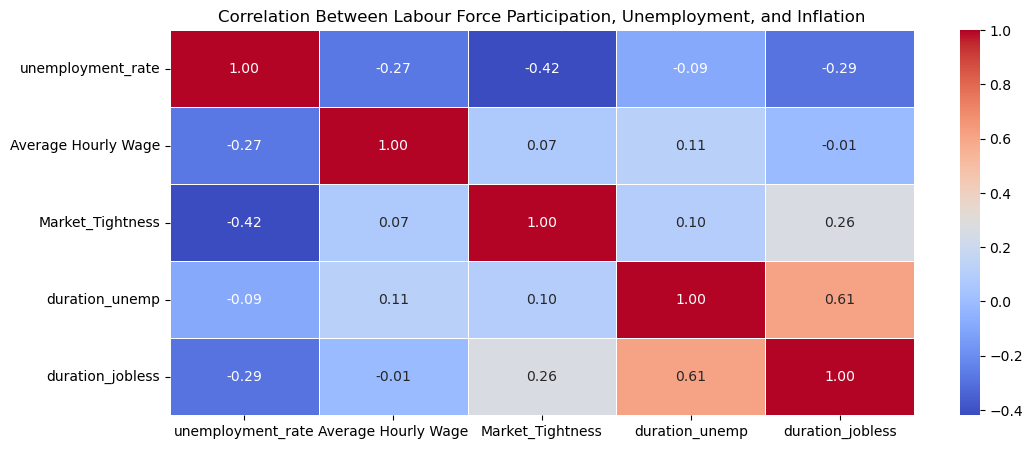

In [33]:
var_of_interest = ['unemployment_rate', 'Average Hourly Wage', 'Market_Tightness', 'duration_unemp', 'duration_jobless']
industry_trends_corr = industry_trends[var_of_interest].corr()
industry_trends_corr

plt.figure(figsize=(12, 5))
sns.heatmap(industry_trends[var_of_interest].corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Between Labour Force Participation, Unemployment, and Inflation")
plt.show()


## How do demographic factors (age, gender, education, etc.) influence unenemployment?

In [34]:
import pandas as pd

def calculate_labour_market_indicators(LFS, category):
    """
    Calculate the weighted Labour Force Participation Rate (LFPR), Unemployment Rate, and Average Hourly Wage by a given category.

    Parameters:
    LFS (pd.DataFrame): The DataFrame containing the labour force survey data.
    category (str): The column name for which the indicators should be calculated.

    Returns:
    Tuple[pd.DataFrame, pd.DataFrame]: 
        - Monthly DataFrame with LFPR, Unemployment Rate, and Average Hourly Wage.
        - Overall DataFrame with average LFPR, Unemployment Rate, and Hourly Wage.
    """

    # Calculate total weighted labour force per category and month
    labour_force = (
        LFS[LFS['lf_status'].isin([1, 2, 3])]
        .groupby(['REF_DATE', category], as_index=False, observed=False)['final_wt']
        .sum()
        .rename(columns={'final_wt': 'weighted_labour_force'})
    )

    # Calculate total weighted working-age population per category and month
    working_age_pop = (
        LFS.groupby(['REF_DATE', category], as_index=False, observed=False)['final_wt']
        .sum()
        .rename(columns={'final_wt': 'weighted_working_age_pop'})
    )

    # Calculate total weighted unemployed per category and month
    unemployed_df = LFS[LFS["lf_status"] == 3]
    unemployed_per_month = (
        unemployed_df.groupby(['REF_DATE', category], as_index=False, observed=False)['final_wt']
        .sum()
        .rename(columns={'final_wt': 'weighted_unemployed'})
    )

    # Calculate weighted average hourly wage per month and category
    employed = LFS[LFS['lf_status'].isin([1, 2])]
    employed_df = employed[(employed['hourly_wage'] != 0) & (~employed['hourly_wage'].isna())]  

    wage_per_month = (
        employed_df.groupby(['REF_DATE', category], as_index=False, observed=False)[['hourly_wage', 'final_wt']]
        .apply(lambda x: pd.Series({
            "avg_hourly_wage": (x['hourly_wage'] * x['final_wt']).sum() / x['final_wt'].sum()
        }))
        .reset_index(drop=True)  # Fix index issue
    )

    # Merge all DataFrames
    indicators_df = labour_force.merge(working_age_pop, on=['REF_DATE', category], how='left')
    indicators_df = indicators_df.merge(unemployed_per_month, on=['REF_DATE', category], how='left')
    indicators_df = indicators_df.merge(wage_per_month, on=['REF_DATE', category], how='left')

    # Compute LFPR and Unemployment Rate
    indicators_df['LFPR_rate'] = (
        (indicators_df['weighted_labour_force'] / indicators_df['weighted_working_age_pop']) * 100
    ).round(2)

    indicators_df['unemployment_rate'] = (
        (indicators_df['weighted_unemployed'] / indicators_df['weighted_labour_force']) * 100
    ).round(2)

    # Calculate overall averages across all months
    total_labour_force = labour_force.groupby(category, as_index=False, observed=False)['weighted_labour_force'].sum()
    total_working_pop = working_age_pop.groupby(category, as_index=False, observed=False)['weighted_working_age_pop'].sum()
    total_unemployed = unemployed_per_month.groupby(category, as_index=False, observed=False)['weighted_unemployed'].sum()

    # Overall weighted average hourly wage
    overall_wage = (
        employed_df.groupby(category, as_index=False, observed=False)[['hourly_wage', 'final_wt']]
        .apply(lambda x: pd.Series({
            "overall_avg_hourly_wage": (x['hourly_wage'] * x['final_wt']).sum() / x['final_wt'].sum()
        }))
        .reset_index(drop=True)  # Fix index issue
    )

    overall_df = pd.DataFrame({
        category: total_labour_force[category],
        "overall_LFPR_rate": (total_labour_force['weighted_labour_force'] / total_working_pop['weighted_working_age_pop'] * 100).round(2),
        "overall_unemployment_rate": (total_unemployed['weighted_unemployed'] / total_labour_force['weighted_labour_force'] * 100).round(2),
    })

    # Merge with overall wage
    overall_df = overall_df.merge(overall_wage, on=category, how="left")

    return indicators_df, overall_df


In [35]:
def calculate_labour_market_indicators_two_categories(LFS, category1, category2):
    """
    Calculate the weighted Labour Force Participation Rate (LFPR), Unemployment Rate, 
    and Average Hourly Wage by two given categories.

    Parameters:
    LFS (pd.DataFrame): The DataFrame containing the labour force survey data.
    category1 (str): The first category column name.
    category2 (str): The second category column name.

    Returns:
    Tuple[pd.DataFrame, pd.DataFrame]: 
        - Monthly DataFrame with LFPR, Unemployment Rate, and Average Hourly Wage.
        - Overall DataFrame with average LFPR, Unemployment Rate, and Hourly Wage.
    """

    group_cols = ['REF_DATE', category1, category2]

    # Calculate total weighted labour force per category combination and month
    labour_force = (
        LFS[LFS['lf_status'].isin([1, 2, 3])]
        .groupby(group_cols, as_index=False, observed=False)['final_wt']
        .sum()
        .rename(columns={'final_wt': 'weighted_labour_force'})
    )

    # Calculate total weighted working-age population per category combination and month
    working_age_pop = (
        LFS.groupby(group_cols, as_index=False, observed=False)['final_wt']
        .sum()
        .rename(columns={'final_wt': 'weighted_working_age_pop'})
    )

    # Calculate total weighted unemployed per category combination and month
    unemployed_df = LFS[LFS["lf_status"] == 3]
    unemployed_per_month = (
        unemployed_df.groupby(group_cols, as_index=False, observed=False)['final_wt']
        .sum()
        .rename(columns={'final_wt': 'weighted_unemployed'})
    )

    # Calculate weighted average hourly wage per month and category combination
    employed = LFS[LFS['lf_status'].isin([1, 2])]
    employed_df = employed[(employed['hourly_wage'] != 0) & (~employed['hourly_wage'].isna())]  

    wage_per_month = (
        employed_df.groupby(group_cols, as_index=False, observed=False)[['hourly_wage', 'final_wt']]
        .apply(lambda x: pd.Series({
            "avg_hourly_wage": (x['hourly_wage'] * x['final_wt']).sum() / x['final_wt'].sum()
        }))
        .reset_index(drop=True)
    )

    # Merge all DataFrames
    indicators_df = labour_force.merge(working_age_pop, on=group_cols, how='left')
    indicators_df = indicators_df.merge(unemployed_per_month, on=group_cols, how='left')
    indicators_df = indicators_df.merge(wage_per_month, on=group_cols, how='left')

    # Compute LFPR and Unemployment Rate
    indicators_df['LFPR_rate'] = (
        (indicators_df['weighted_labour_force'] / indicators_df['weighted_working_age_pop']) * 100
    ).round(2)

    indicators_df['unemployment_rate'] = (
        (indicators_df['weighted_unemployed'] / indicators_df['weighted_labour_force']) * 100
    ).round(2)

    # Calculate overall averages across all months
    total_labour_force = labour_force.groupby([category1, category2], as_index=False, observed=False)['weighted_labour_force'].sum()
    total_working_pop = working_age_pop.groupby([category1, category2], as_index=False, observed=False)['weighted_working_age_pop'].sum()
    total_unemployed = unemployed_per_month.groupby([category1, category2], as_index=False, observed=False)['weighted_unemployed'].sum()

    # Overall weighted average hourly wage
    overall_wage = (
        employed_df.groupby([category1, category2], as_index=False, observed=False)[['hourly_wage', 'final_wt']]
        .apply(lambda x: pd.Series({
            "overall_avg_hourly_wage": (x['hourly_wage'] * x['final_wt']).sum() / x['final_wt'].sum()
        }))
        .reset_index(drop=True)
    )

    overall_df = pd.DataFrame({
        category1: total_labour_force[category1],
        category2: total_labour_force[category2],
        "overall_LFPR_rate": (total_labour_force['weighted_labour_force'] / total_working_pop['weighted_working_age_pop'] * 100).round(2),
        "overall_unemployment_rate": (total_unemployed['weighted_unemployed'] / total_labour_force['weighted_labour_force'] * 100).round(2),
    })

    # Merge with overall wage
    overall_df = overall_df.merge(overall_wage, on=[category1, category2], how="left")

    return indicators_df, overall_df


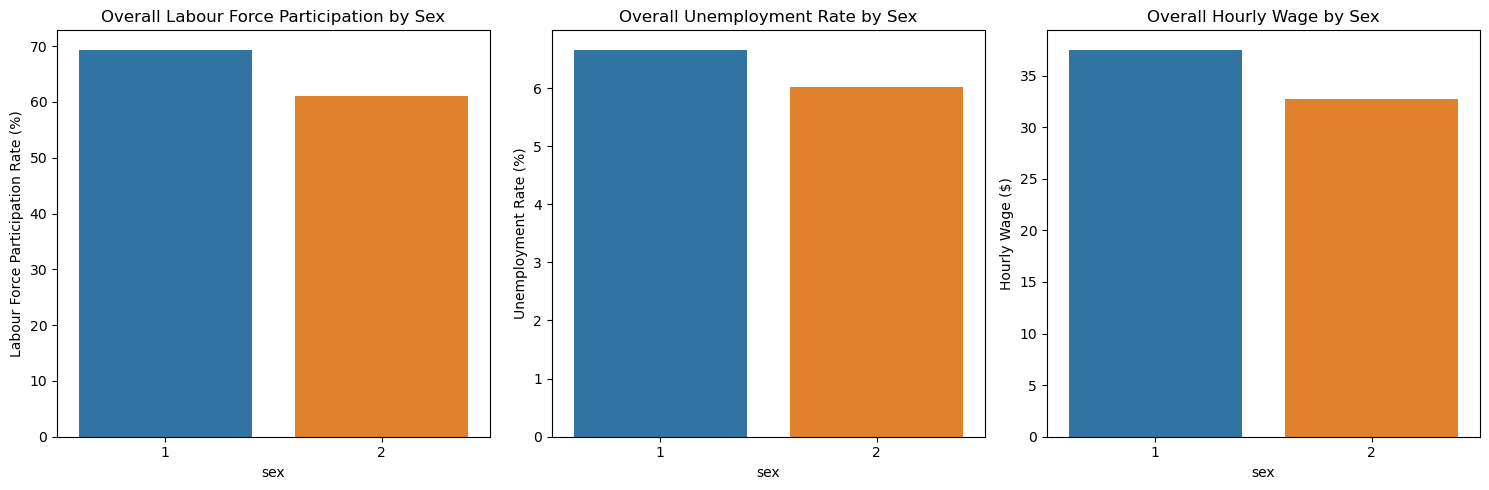

In [37]:
# Calculating Labour Force Participation Rate and Unemployment Rate by demographic groups
monthly_rates_by_gender, overall_rates_by_gender = calculate_labour_market_indicators(LFS, 'sex')
# Create a figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(15, 5))  # Adjust figsize as needed

# Labour Force Participation Rate Plot
sns.barplot(data=overall_rates_by_gender, x='sex', y='overall_LFPR_rate', hue='sex', ax=axes[0], legend=False)
axes[0].set_title('Overall Labour Force Participation by Sex')
axes[0].set_ylabel('Labour Force Participation Rate (%)')

# Unemployment Rate Plot
sns.barplot(data=overall_rates_by_gender, x='sex', y='overall_unemployment_rate', hue='sex', ax=axes[1], legend=False)
axes[1].set_title('Overall Unemployment Rate by Sex')
axes[1].set_ylabel('Unemployment Rate (%)')

# Hourly Wage Plot
sns.barplot(data=overall_rates_by_gender, x='sex', y='overall_avg_hourly_wage', hue='sex', ax=axes[2], legend=False)
axes[2].set_title('Overall Hourly Wage by Sex')
axes[2].set_ylabel('Hourly Wage ($)')

# Adjust layout for better spacing
plt.tight_layout()
plt.show()


In [69]:
monthly_rates_by_age, overall_rates_by_age = calculate_labour_market_indicators(LFS, '5y_age')
# Create a figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # Adjust figsize as needed

# Labour Force Participation Rate Plot
sns.barplot(data=overall_rates_by_age, x='5y_age', y='overall_LFPR_rate', hue='5y_age', ax=axes[0], legend=False)
axes[0].set_title('Overall Labour Force Participation by Age')
axes[0].set_ylabel('Labour Force Participation Rate (%)')
axes[0].tick_params(axis='x', rotation=45)  # Rotate x-axis labels for better readability

# Unemployment Rate Plot
sns.barplot(data=overall_rates_by_age, x='5y_age', y='overall_unemployment_rate', hue='5y_age', ax=axes[1], legend=False)
axes[1].set_title('Overall Unemployment Rate by Age')
axes[1].set_ylabel('Unemployment Rate (%)')
axes[1].tick_params(axis='x', rotation=45)

# Hourly Wage Plot
sns.barplot(data=overall_rates_by_age, x='5y_age', y='overall_avg_hourly_wage', hue='5y_age', ax=axes[2], legend=False)
axes[2].set_title('Overall Hourly Wage by Age')
axes[2].set_ylabel('Hourly Wage ($)')
axes[2].tick_params(axis='x', rotation=45)

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

KeyError: '5y_age'

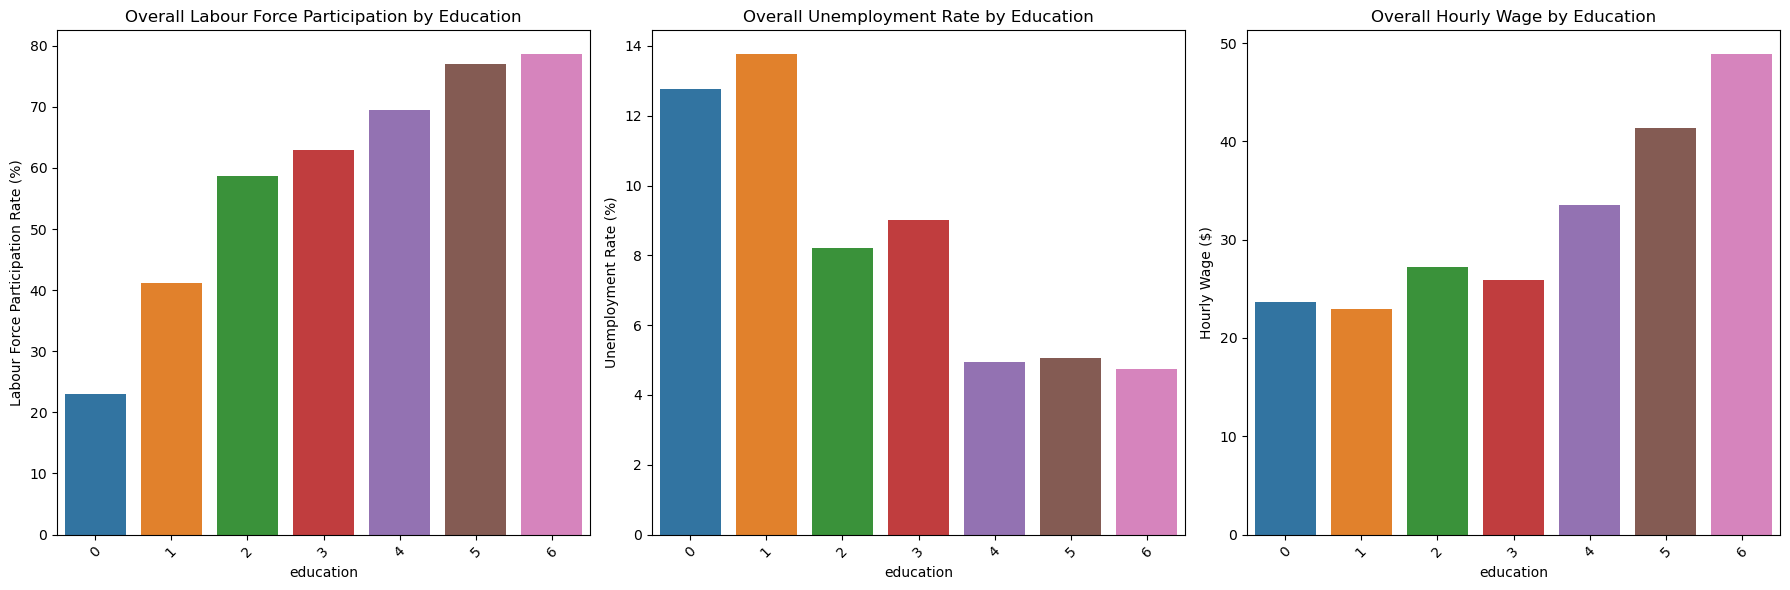

In [39]:
monthly_rates_by_education, overall_rates_by_education = calculate_labour_market_indicators(LFS, 'education')
# Create a figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # Adjust figsize as needed

# Labour Force Participation Rate Plot
sns.barplot(data=overall_rates_by_education, x='education', y='overall_LFPR_rate', hue='education', ax=axes[0], legend=False)
axes[0].set_title('Overall Labour Force Participation by Education')
axes[0].set_ylabel('Labour Force Participation Rate (%)')
axes[0].tick_params(axis='x', rotation=45)  # Rotate x-axis labels for better readability

# Unemployment Rate Plot
sns.barplot(data=overall_rates_by_education, x='education', y='overall_unemployment_rate', hue='education', ax=axes[1], legend=False)
axes[1].set_title('Overall Unemployment Rate by Education')
axes[1].set_ylabel('Unemployment Rate (%)')
axes[1].tick_params(axis='x', rotation=45)

# Hourly Wage Plot
sns.barplot(data=overall_rates_by_education, x='education', y='overall_avg_hourly_wage', hue='education', ax=axes[2], legend=False)
axes[2].set_title('Overall Hourly Wage by Education')
axes[2].set_ylabel('Hourly Wage ($)')
axes[2].tick_params(axis='x', rotation=45)

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

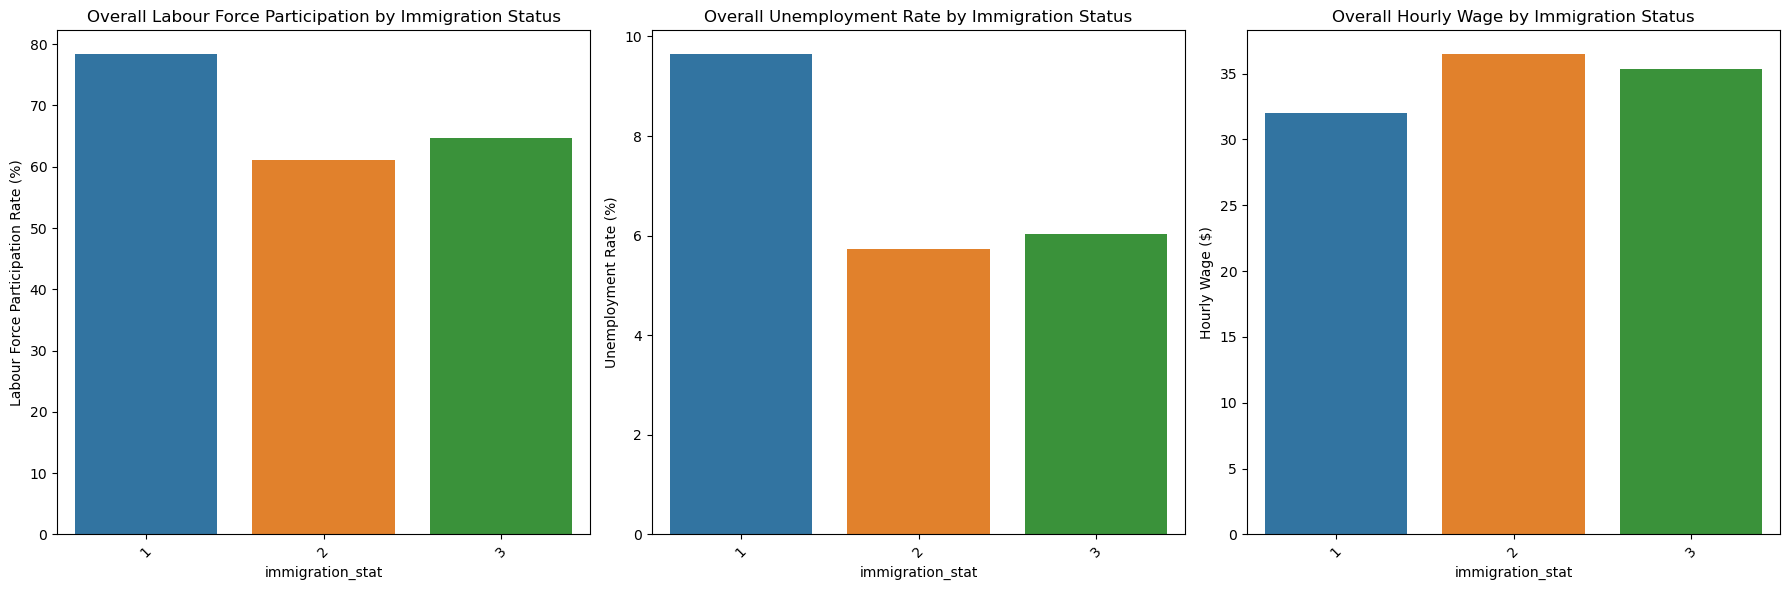

In [40]:
monthly_rates_by_immigration, overall_rates_by_immigration = calculate_labour_market_indicators(LFS, 'immigration_stat')
# Create a figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # Adjust figsize as needed

# Labour Force Participation Rate Plot
sns.barplot(data=overall_rates_by_immigration, x='immigration_stat', y='overall_LFPR_rate', hue='immigration_stat', ax=axes[0], legend=False)
axes[0].set_title('Overall Labour Force Participation by Immigration Status')
axes[0].set_ylabel('Labour Force Participation Rate (%)')
axes[0].tick_params(axis='x', rotation=45)  # Rotate x-axis labels for readability

# Unemployment Rate Plot
sns.barplot(data=overall_rates_by_immigration, x='immigration_stat', y='overall_unemployment_rate', hue='immigration_stat', ax=axes[1], legend=False)
axes[1].set_title('Overall Unemployment Rate by Immigration Status')
axes[1].set_ylabel('Unemployment Rate (%)')
axes[1].tick_params(axis='x', rotation=45)

# Hourly Wage Plot
sns.barplot(data=overall_rates_by_immigration, x='immigration_stat', y='overall_avg_hourly_wage', hue='immigration_stat', ax=axes[2], legend=False)
axes[2].set_title('Overall Hourly Wage by Immigration Status')
axes[2].set_ylabel('Hourly Wage ($)')
axes[2].tick_params(axis='x', rotation=45)

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

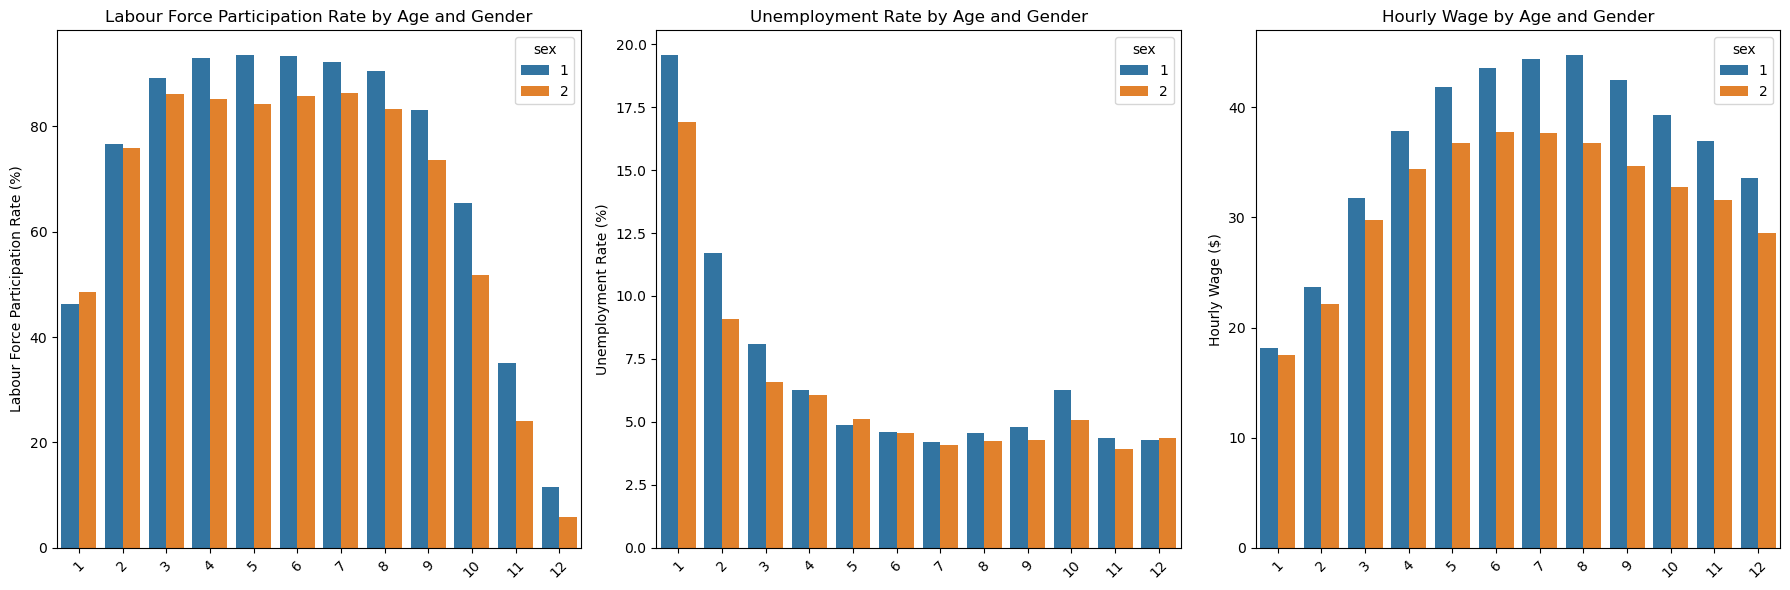

In [41]:
# Calculation LFPR and Unemployment based on age and gender
monthly_age_sex_df, overall_age_sex_df =calculate_labour_market_indicators_two_categories(LFS, '5y_age', 'sex')


import seaborn as sns
import matplotlib.pyplot as plt

# Create a figure with 3 subplots side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Labour Force Participation Rate
sns.barplot(data=overall_age_sex_df, x='5y_age', y='overall_LFPR_rate', hue='sex', ax=axes[0])
axes[0].set_title('Labour Force Participation Rate by Age and Gender')
axes[0].set_ylabel('Labour Force Participation Rate (%)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)  # Rotate x-axis labels

# Unemployment Rate
sns.barplot(data=overall_age_sex_df, x='5y_age', y='overall_unemployment_rate', hue='sex', ax=axes[1])
axes[1].set_title('Unemployment Rate by Age and Gender')
axes[1].set_ylabel('Unemployment Rate (%)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)

# Hourly Wage
sns.barplot(data=overall_age_sex_df, x='5y_age', y='overall_avg_hourly_wage', hue='sex', ax=axes[2])
axes[2].set_title('Hourly Wage by Age and Gender')
axes[2].set_ylabel('Hourly Wage ($)')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=45)

# Adjust layout and show
plt.tight_layout()
plt.show()


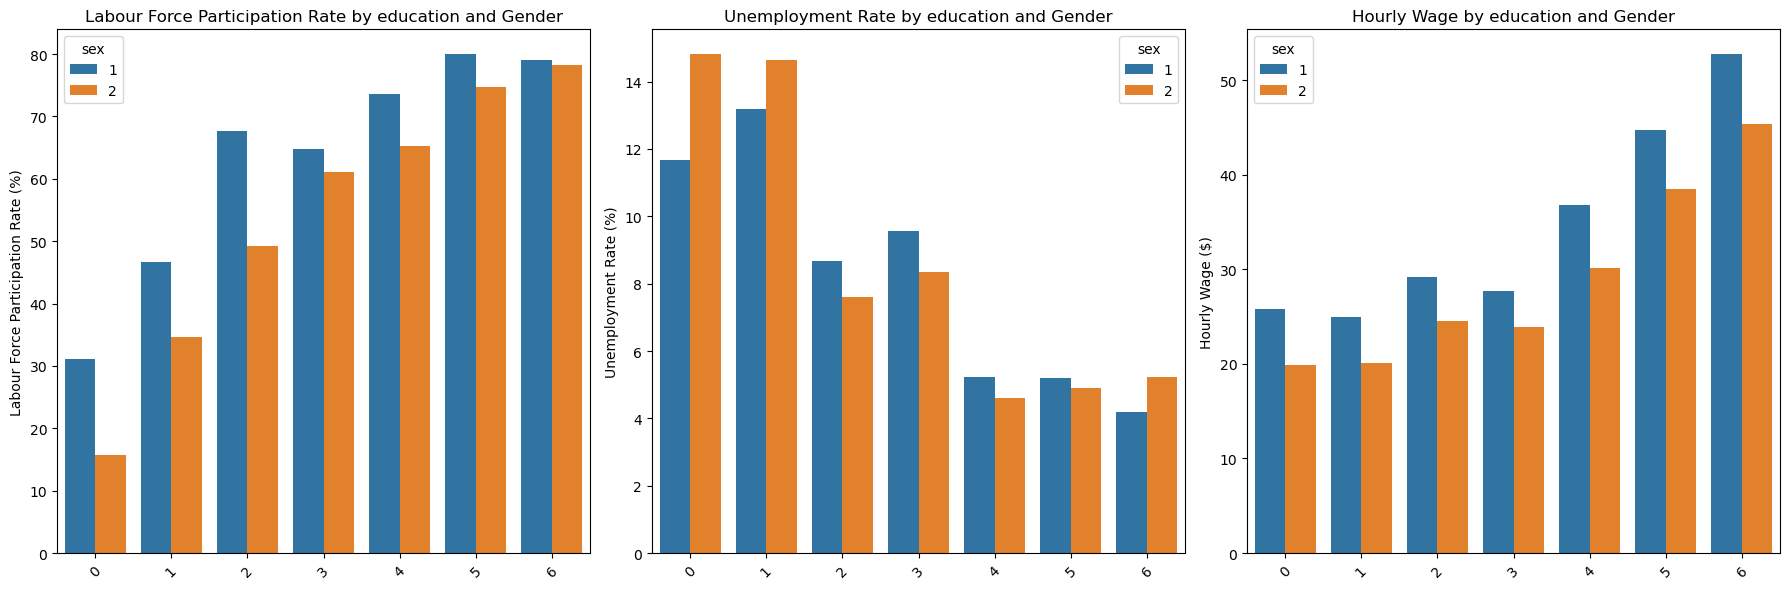

In [42]:
# Calculation LFPR and Unemployment based on education level and gender
monthly_education_sex_df, overall_education_sex_df = calculate_labour_market_indicators_two_categories(LFS, 'education', 'sex')


import seaborn as sns
import matplotlib.pyplot as plt

# Create a figure with 3 subplots side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Labour Force Participation Rate
sns.barplot(data=overall_education_sex_df, x='education', y='overall_LFPR_rate', hue='sex', ax=axes[0])
axes[0].set_title('Labour Force Participation Rate by education and Gender')
axes[0].set_ylabel('Labour Force Participation Rate (%)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)  # Rotate x-axis labels

# Unemployment Rate
sns.barplot(data=overall_education_sex_df, x='education', y='overall_unemployment_rate', hue='sex', ax=axes[1])
axes[1].set_title('Unemployment Rate by education and Gender')
axes[1].set_ylabel('Unemployment Rate (%)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)

# Hourly Wage
sns.barplot(data=overall_education_sex_df, x='education', y='overall_avg_hourly_wage', hue='sex', ax=axes[2])
axes[2].set_title('Hourly Wage by education and Gender')
axes[2].set_ylabel('Hourly Wage ($)')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=45)

# Adjust layout and show
plt.tight_layout()
plt.show()


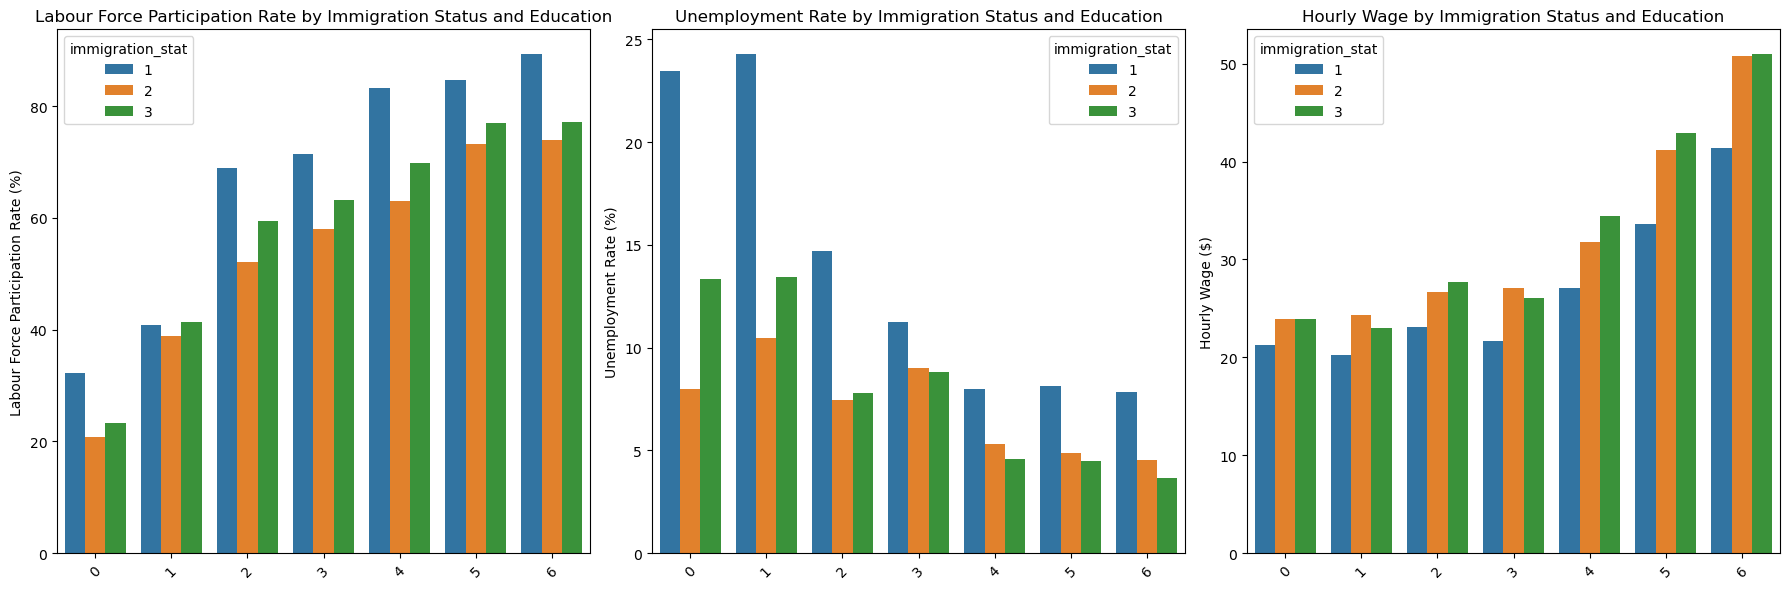

In [ ]:
# Calculation LFPR and Unemployment based on education level and gender
monthly_education_immigration_df, overall_education_immigration_df = calculate_labour_market_indicators_two_categories(LFS, 'education', 'immigration_stat')

# Create a figure with 3 subplots side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Labour Force Participation Rate
sns.barplot(data=overall_education_immigration_df, x='education', y='overall_LFPR_rate', hue='immigration_stat', ax=axes[0])
axes[0].set_title('Labour Force Participation Rate by Immigration Status and Education')
axes[0].set_ylabel('Labour Force Participation Rate (%)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)  # Rotate x-axis labels

# Unemployment Rate
sns.barplot(data=overall_education_immigration_df, x='education', y='overall_unemployment_rate', hue='immigration_stat', ax=axes[1])
axes[1].set_title('Unemployment Rate by Immigration Status and Education')
axes[1].set_ylabel('Unemployment Rate (%)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)

# Hourly Wage
sns.barplot(data=overall_education_immigration_df, x='education', y='overall_avg_hourly_wage', hue='immigration_stat', ax=axes[2])
axes[2].set_title('Hourly Wage by Immigration Status and Education')
axes[2].set_ylabel('Hourly Wage ($)')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=45)

# Adjust layout and show
plt.tight_layout()
plt.show()


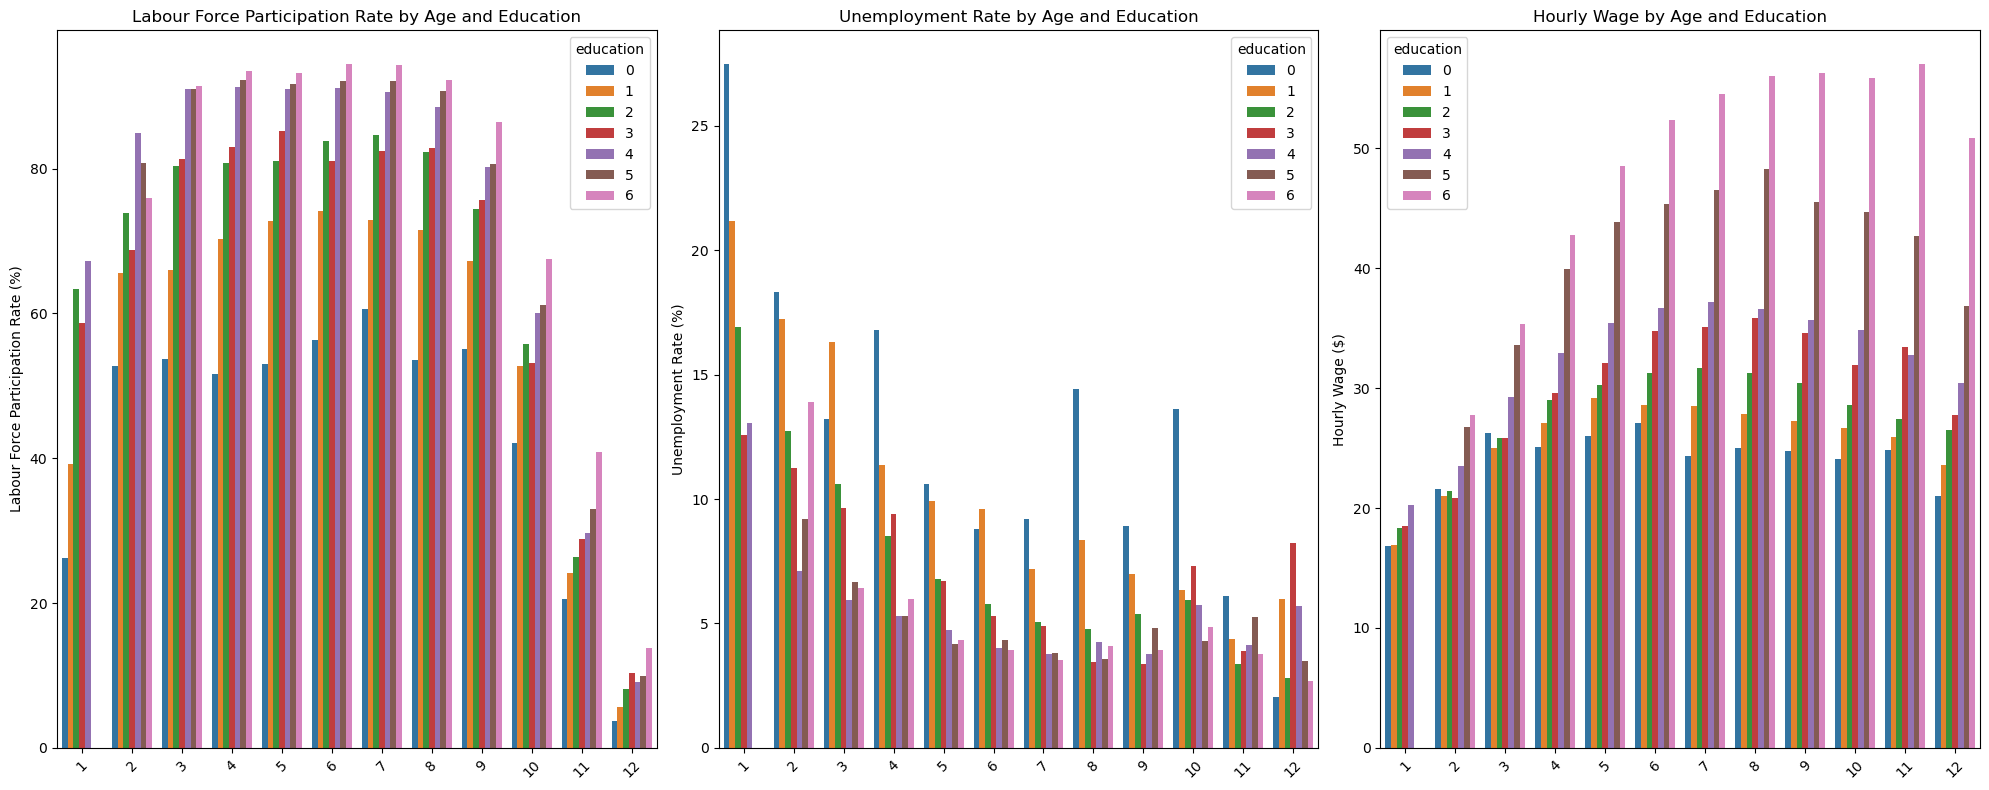

In [47]:
# Calculation LFPR and Unemployment based on education level and gender
monthly_education_age_df, overall_education_age_df = calculate_labour_market_indicators_two_categories(LFS, 'education', '5y_age')

# Create a figure with 3 subplots side by side
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

# Labour Force Participation Rate
sns.barplot(data=overall_education_age_df, x='5y_age', y='overall_LFPR_rate', hue='education', ax=axes[0])
axes[0].set_title('Labour Force Participation Rate by Age and Education')
axes[0].set_ylabel('Labour Force Participation Rate (%)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)  # Rotate x-axis labels

# Unemployment Rate
sns.barplot(data=overall_education_age_df, x='5y_age', y='overall_unemployment_rate', hue='education', ax=axes[1])
axes[1].set_title('Unemployment Rate by Age and Education')
axes[1].set_ylabel('Unemployment Rate (%)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)

# Hourly Wage
sns.barplot(data=overall_education_age_df, x='5y_age', y='overall_avg_hourly_wage', hue='education', ax=axes[2])
axes[2].set_title('Hourly Wage by Age and Education')
axes[2].set_ylabel('Hourly Wage ($)')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=45)

# Adjust layout and show
plt.tight_layout()
plt.show()


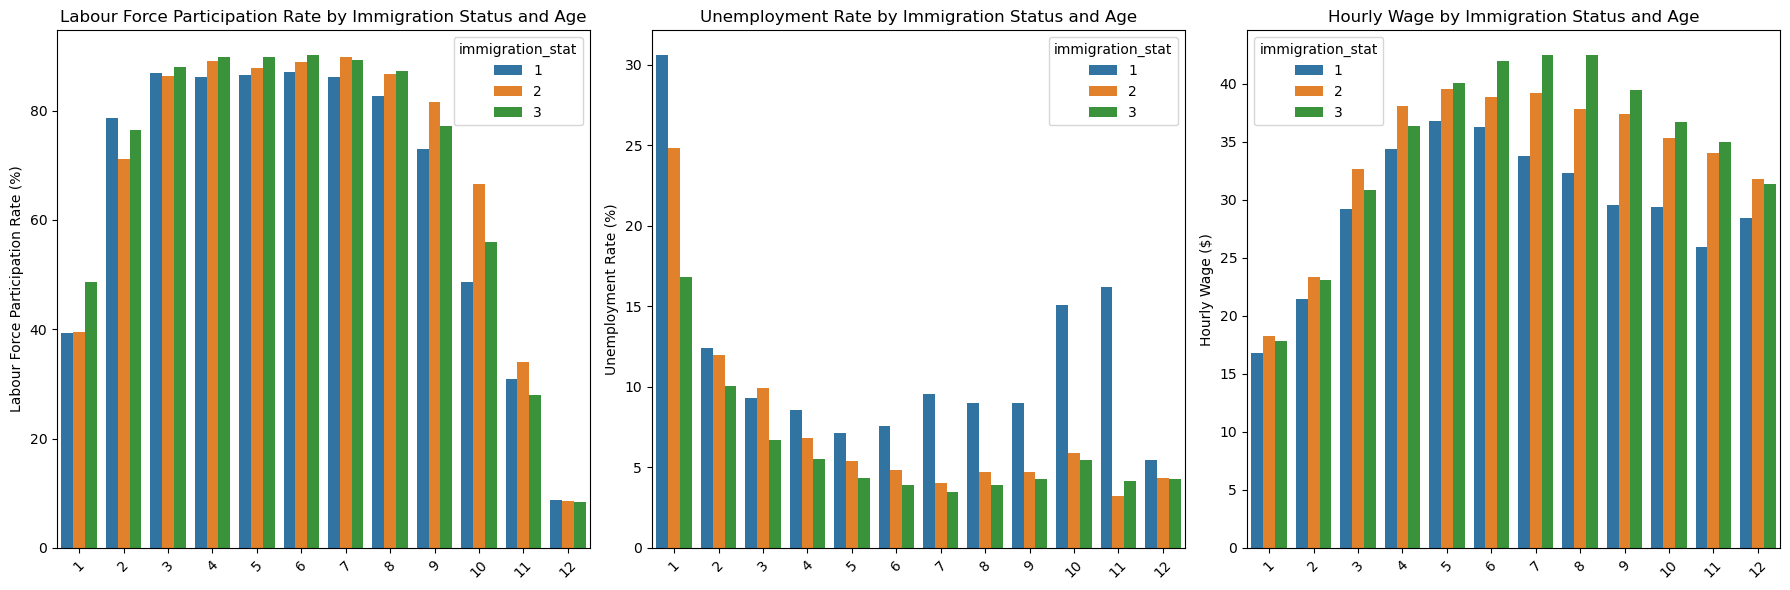

In [49]:
# Calculation LFPR and Unemployment based on education level and gender
monthly_age_immigration_df, overall_age_immigration_df = calculate_labour_market_indicators_two_categories(LFS, '5y_age', 'immigration_stat')

# Create a figure with 3 subplots side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Labour Force Participation Rate
sns.barplot(data=overall_age_immigration_df, x='5y_age', y='overall_LFPR_rate', hue='immigration_stat', ax=axes[0])
axes[0].set_title('Labour Force Participation Rate by Immigration Status and Age')
axes[0].set_ylabel('Labour Force Participation Rate (%)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)  # Rotate x-axis labels

# Unemployment Rate
sns.barplot(data=overall_age_immigration_df, x='5y_age', y='overall_unemployment_rate', hue='immigration_stat', ax=axes[1])
axes[1].set_title('Unemployment Rate by Immigration Status and Age')
axes[1].set_ylabel('Unemployment Rate (%)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)

# Hourly Wage
sns.barplot(data=overall_age_immigration_df, x='5y_age', y='overall_avg_hourly_wage', hue='immigration_stat', ax=axes[2])
axes[2].set_title('Hourly Wage by Immigration Status and Age')
axes[2].set_ylabel('Hourly Wage ($)')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=45)

# Adjust layout and show
plt.tight_layout()
plt.show()


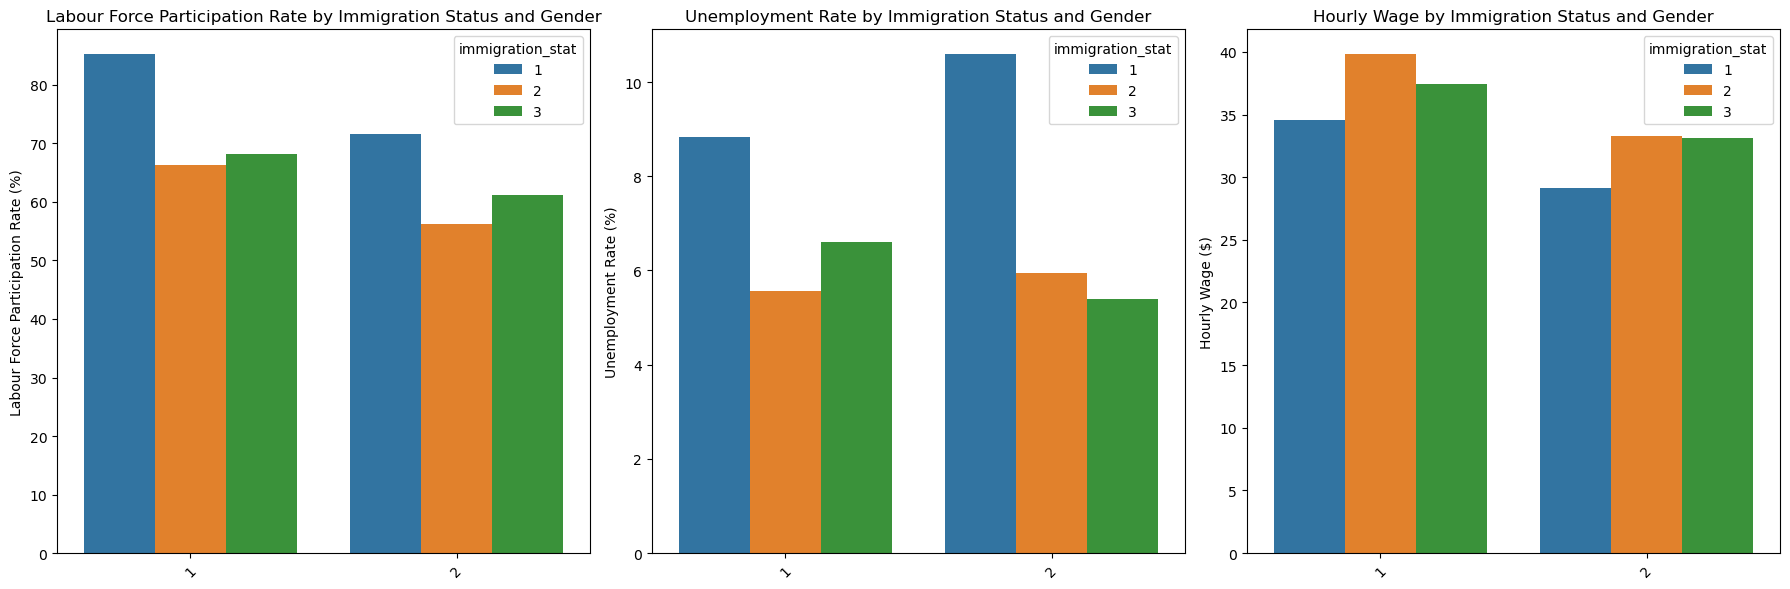

In [50]:
# Calculation LFPR and Unemployment based on education level and gender
monthly_gender_immigration_df, overall_gender_immigration_df = calculate_labour_market_indicators_two_categories(LFS, 'sex', 'immigration_stat')

# Create a figure with 3 subplots side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Labour Force Participation Rate
sns.barplot(data=overall_gender_immigration_df, x='sex', y='overall_LFPR_rate', hue='immigration_stat', ax=axes[0])
axes[0].set_title('Labour Force Participation Rate by Immigration Status and Gender')
axes[0].set_ylabel('Labour Force Participation Rate (%)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)  # Rotate x-axis labels

# Unemployment Rate
sns.barplot(data=overall_gender_immigration_df, x='sex', y='overall_unemployment_rate', hue='immigration_stat', ax=axes[1])
axes[1].set_title('Unemployment Rate by Immigration Status and Gender')
axes[1].set_ylabel('Unemployment Rate (%)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)

# Hourly Wage
sns.barplot(data=overall_gender_immigration_df, x='sex', y='overall_avg_hourly_wage', hue='immigration_stat', ax=axes[2])
axes[2].set_title('Hourly Wage by Immigration Status and Gender')
axes[2].set_ylabel('Hourly Wage ($)')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=45)

# Adjust layout and show
plt.tight_layout()
plt.show()


In [63]:
import statsmodels.formula.api as smf

# Creating a binary column for employment status
LFS['unemployed_binary'] = (LFS['lf_status'] == 3).astype(int)  # 1 if unemployed, 0 otherwise
LFS = LFS.rename(columns={"5y_age": "age_group_5y"})

features = ['age_group_5y', 'sex', 'education', 'immigration_stat']

# Baseline model for Unemployment
baseline_model = smf.logit("unemployed_binary ~ age_group_5y + sex + education + immigration_stat", data=LFS).fit()

# Print summary
print(baseline_model.summary())

Optimization terminated successfully.
         Current function value: 0.153234
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:      unemployed_binary   No. Observations:              1343036
Model:                          Logit   Df Residuals:                  1343015
Method:                           MLE   Df Model:                           20
Date:                Tue, 11 Mar 2025   Pseudo R-squ.:                 0.06322
Time:                        23:25:48   Log-Likelihood:            -2.0580e+05
converged:                       True   LL-Null:                   -2.1969e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                -1.8190      0.032    -57.501      0.000      -1.881      -1

In [56]:
# Compute Marginal Effects
marginal_effects = baseline_model.get_margeff()
print(marginal_effects.summary())

        Logit Marginal Effects       
Dep. Variable:      unemployed_binary
Method:                          dydx
At:                           overall
                           dy/dx    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
age_group_5y[T.2]         0.0024      0.001      3.458      0.001       0.001       0.004
age_group_5y[T.3]        -0.0030      0.001     -3.973      0.000      -0.004      -0.002
age_group_5y[T.4]        -0.0132      0.001    -17.159      0.000      -0.015      -0.012
age_group_5y[T.5]        -0.0185      0.001    -23.398      0.000      -0.020      -0.017
age_group_5y[T.6]        -0.0218      0.001    -26.967      0.000      -0.023      -0.020
age_group_5y[T.7]        -0.0241      0.001    -28.692      0.000      -0.026      -0.022
age_group_5y[T.8]        -0.0246      0.001    -29.365      0.000      -0.026      -0.023
age_group_5y[T.9]        -0.0271      

### Logistic Regression Results Summary

### Key Findings:

- **Age:** Unemployment likelihood decreases with age. The youngest age group (15-19 years) serves as the reference category. Individuals in the 20-24 age group have a slightly higher probability of being unemployed (+0.24%), while all older groups exhibit significantly lower unemployment probabilities. Notably, those aged 70 and over are least likely to be unemployed (-11.37%).

- **Gender:** Women (coded as 2) have a **lower** likelihood of unemployment than men by approximately 0.87%.

- **Education:** Compared to individuals with 0-8 years of education (reference group), those with:
  - Some high school education have a **slightly higher** likelihood of unemployment (+0.24%).
  - A high school diploma shows no statistically significant difference.
  - Postsecondary education, bachelor's degrees, and higher levels of education **reduce** unemployment risk (ranging from -1.11% to -1.43%).

- **Immigration Status:** 
  - Immigrants who landed **more than 10 years ago** have a **17.7% lower** probability of unemployment than recent immigrants.
  - Recent immigrants (landed ≤10 years) also show a **12.8% lower** unemployment probability compared to the reference category.

### Interpretation:

- **Younger individuals (15-24 years)** are at the highest risk of unemployment.
- **Higher education** significantly reduces unemployment risk, especially beyond high school.
- **Women** are **less likely** to be unemployed than men.
- **Longer residency in Canada** correlates with **lower unemployment**, suggesting labor market integration over time.

These insights highlight the importance of education, age, and immigration status in labor market outcomes.


## What is the average duration of joblessness, and how does it vary across demographic groups, industries?

In [ ]:
LFS_worked_past = LFS_sorted.loc[(LFS['work_lasty'] == 1) | (LFS['work_lasty'] == 2)]
LFS_worked_past.shape

(463586, 52)

<Axes: xlabel='duration_jobless', ylabel='Count'>

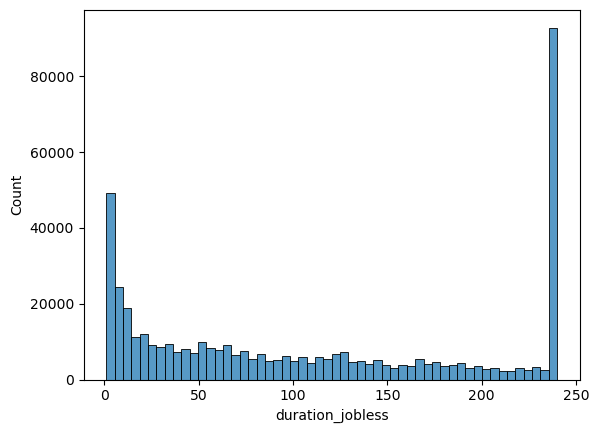

In [ ]:
sns.histplot(LFS_worked_past['duration_jobless'])

Calculatings total average joblessness & total average joblessness per month

Average duration of joblessness from Jan - Nov 2024 is 109.26 months


/var/folders/n9/29yl9jnj61q74vg3ydjdf3qh0000gn/T/ipykernel_8687/2671935996.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_monthly_jobless = LFS_worked_past.groupby(['month'])['duration_jobless'].mean().round(2)


<Axes: xlabel='month', ylabel='duration_jobless'>

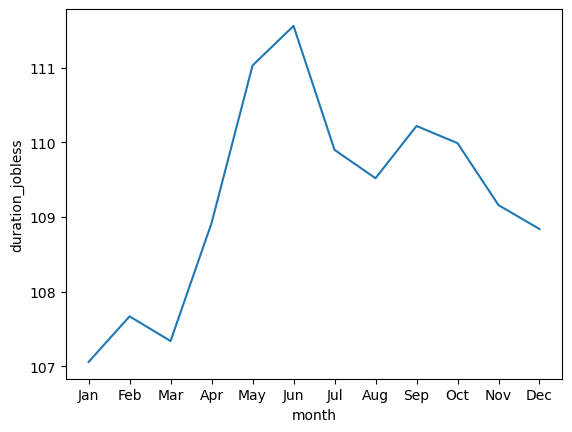

In [ ]:
total_jobless = LFS_worked_past['duration_jobless'].mean()
print(f"Average duration of joblessness from Jan - Nov 2024 is {total_jobless.round(2)} months")

avg_monthly_jobless = LFS_worked_past.groupby(['month'])['duration_jobless'].mean().round(2)
avg_monthly_jobless

sns.lineplot(avg_monthly_jobless)

In [ ]:
# Group by demographic group and calculate average joblessness
avg_joblessness_sex = LFS_worked_past.groupby('sex')['duration_jobless'].mean()
print("Average Joblessness by Sex:")
print(avg_joblessness_sex)

Average Joblessness by Sex:
sex
1    99.253
2   117.423
Name: duration_jobless, dtype: float64


The results of the Kolmogorov-Smirnov Normality test:
Kolmogorov-Smirnov test for group A: D=0.1404507021243091, p-value=0.0
Kolmogorov-Smirnov test for group B: D=0.12828203927993487, p-value=0.0
The groups are not normally distributed



NameError: name 'stats' is not defined

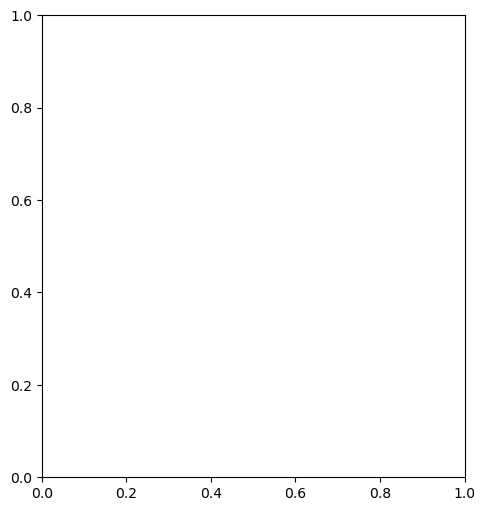

In [ ]:
from scipy.stats import mannwhitneyu, kstest, norm
# Separate data into two groups based on the sex
F_jobless = LFS_worked_past[LFS_worked_past['sex'] == 2]['duration_jobless']
M_jobless = LFS_worked_past[LFS_worked_past['sex'] == 1]['duration_jobless']

# Checking for normality
# Step 2: Check for normality using the Shapiro-Wilk test
ks_A = kstest(F_jobless, 'norm', args=(F_jobless.mean(), F_jobless.std()))
ks_B = kstest(M_jobless, 'norm', args=(M_jobless.mean(), M_jobless.std()))

print('The results of the Kolmogorov-Smirnov Normality test:')
print(f"Kolmogorov-Smirnov test for group A: D={ks_A.statistic}, p-value={ks_A.pvalue}")
print(f"Kolmogorov-Smirnov test for group B: D={ks_B.statistic}, p-value={ks_B.pvalue}")


if ks_A.pvalue > 0.05 and ks_B.pvalue > 0.05:
    print('The groups are normally distributed\n')
else: 
    print('The groups are not normally distributed\n')

    # Step 3: Visualize normality with Q-Q plots
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
stats.probplot(F_jobless, dist="norm", plot=plt)
plt.title('Q-Q Plot for Females')

plt.subplot(1, 2, 2)
stats.probplot(M_jobless, dist="norm", plot=plt)
plt.title('Q-Q Plot for Males')

plt.tight_layout()
plt.show()

# Perform the Wilcoxon rank-sum test (Mann-Whitney U test)
u_stat, p_value = mannwhitneyu(F_jobless, M_jobless, alternative='two-sided')

print('The results of the Wilcoxon rank-sum test:')
print(f"U-statistic: {u_stat}")
print(f"P-value: {p_value}\n")

# Determine if the result is statistically significant
alpha_1 = 0.05  # First significance level
alpha_2 = 0.01  # Second significance level

if p_value < alpha_2:
    print("The difference in means of duration of joblessness between Males and Females is highly statistically significant at the 0.01 level.")
elif p_value < alpha_1:
    print("The difference in means of duration of joblessness between Males and Females is statistically significant at the 0.05 level.")
else:
    print("The difference in means of duration of joblessness between Males and Females is not statistically significant at the 0.05 level.")

In [ ]:
# Group by immigration status and calculate average joblessness
avg_joblessness_immig = LFS_worked_past.groupby('immigration_stat')['duration_jobless'].mean()
print("Average Joblessness by Immigration Status:")
print(avg_joblessness_immig)

Average Joblessness by Immigration Status:
immigration_stat
1    45.333
2   123.484
3   109.069
Name: duration_jobless, dtype: float64


In [ ]:
new_immig_jobless = LFS_worked_past[LFS_worked_past['immigration_stat'] == 1]['duration_jobless']
old_immig_jobless= LFS_worked_past[LFS_worked_past['immigration_stat'] == 2]['duration_jobless']
nonimmig_jobless = LFS_worked_past[LFS_worked_past['immigration_stat'] == 3]['duration_jobless']

ks_A = kstest(new_immig_jobless, 'norm', args=(new_immig_jobless.mean(), new_immig_jobless.std()))
ks_B = kstest(old_immig_jobless, 'norm', args=(old_immig_jobless.mean(), old_immig_jobless.std()))
ks_C = kstest(nonimmig_jobless, 'norm', args=(nonimmig_jobless.mean(), nonimmig_jobless.std()))

print('The results of the Kolmogorov-Smirnov Normality test:')
print(f"Kolmogorov-Smirnov test for group A: D={ks_A.statistic}, p-value={ks_A.pvalue}")
print(f"Kolmogorov-Smirnov test for group B: D={ks_B.statistic}, p-value={ks_B.pvalue}")
print(f"Kolmogorov-Smirnov test for group B: D={ks_C.statistic}, p-value={ks_C.pvalue}\n")

if ks_A.pvalue > 0.05 and ks_B.pvalue > 0.05 and ks_C.pvalue > 0.05:
    print('The groups are normally distributed\n')
else: 
    print('The groups are not normally distributed\n')

# Performing Kruskal Wallis Test
stat, p_value = kruskal(new_immig_jobless, old_immig_jobless, nonimmig_jobless)
print('The results of the Kruskal Wallis Test:')
print(f"Kruskal-Wallis H-statistic: {stat}")
print(f"P-value: {p_value}\n")

if p_value < alpha_2:
    print("The difference between groups is statistically significant at the 0.01 level.")
elif p_value < alpha_1:
    print("The difference between groups is statistically significant at the 0.05 level.")
else:
    print("The difference between groups is not statistically significant at the 0.05 level.")

The results of the Kolmogorov-Smirnov Normality test:
Kolmogorov-Smirnov test for group A: D=0.23835391249732246, p-value=0.0
Kolmogorov-Smirnov test for group B: D=0.14228591907063204, p-value=0.0
Kolmogorov-Smirnov test for group B: D=0.122722099538771, p-value=0.0

The groups are not normally distributed

The results of the Kruskal Wallis Test:
Kruskal-Wallis H-statistic: 10633.493133405951
P-value: 0.0

The difference between groups is statistically significant at the 0.01 level.


In [ ]:
groups = []
group_names = LFS_worked_past['education'].unique()

for group in LFS_worked_past['education'].unique():
    groups.append(LFS_worked_past[LFS_worked_past['education'] == group]['duration_jobless'])

# Step 3: Check for normality using the Kolmogorov-Smirnov test
for group_name, group in zip(group_names, groups):
    ks_stat, ks_pvalue = kstest(group, 'norm', args=(group.mean(), group.std()))
    print(f"Kolmogorov-Smirnov test for group {group_name}: D={ks_stat}, p-value={ks_pvalue}")
    if ks_pvalue > 0.05:
        print(f"Group {group_name} is normally distributed\n")
    else:
        print(f"Group {group_name} is not normally distributed\n")
        
# Step 3: Perform the Kruskal-Wallis test
stat, p_value = kruskal(*groups)

print('The results of the Kruskal Wallis Test:')
print(f"Kruskal-Wallis H-statistic: {stat}")
print(f"P-value: {p_value}")

# Determine if the result is statistically significant
alpha_1 = 0.05  # First significance level
alpha_2 = 0.01  # Second significance level

if p_value < alpha_2:
    print("The difference between groups is statistically significant at the 0.01 level.")
elif p_value < alpha_1:
    print("The difference between groups is statistically significant at the 0.05 level.")
else:
    print("The difference between groups is not statistically significant at the 0.05 level.")


Kolmogorov-Smirnov test for group 2: D=0.12056355853290279, p-value=0.0
Group 2 is not normally distributed

Kolmogorov-Smirnov test for group 4: D=0.10956117943907662, p-value=0.0
Group 4 is not normally distributed

Kolmogorov-Smirnov test for group 1: D=0.15780215653837004, p-value=0.0
Group 1 is not normally distributed

Kolmogorov-Smirnov test for group 0: D=0.23694154146199975, p-value=0.0
Group 0 is not normally distributed

Kolmogorov-Smirnov test for group 5: D=0.12248239332865862, p-value=0.0
Group 5 is not normally distributed

Kolmogorov-Smirnov test for group 3: D=0.18561738455922672, p-value=0.0
Group 3 is not normally distributed

Kolmogorov-Smirnov test for group 6: D=0.12137073169156204, p-value=0.0
Group 6 is not normally distributed

The results of the Kruskal Wallis Test:
Kruskal-Wallis H-statistic: 12344.035901666673
P-value: 0.0
The difference between groups is statistically significant at the 0.01 level.


In [ ]:
groups = []
group_names = LFS_worked_past['marital_stat'].unique()

for group in LFS_worked_past['marital_stat'].unique():
    groups.append(LFS_worked_past[LFS_worked_past['marital_stat'] == group]['duration_jobless'])

# Step 3: Check for normality using the Kolmogorov-Smirnov test
for group_name, group in zip(group_names, groups):
    ks_stat, ks_pvalue = kstest(group, 'norm', args=(group.mean(), group.std()))
    print(f"Kolmogorov-Smirnov test for group {group_name}: D={ks_stat}, p-value={ks_pvalue}")
    if ks_pvalue > 0.05:
        print(f"Group {group_name} is normally distributed\n")
    else:
        print(f"Group {group_name} is not normally distributed\n")

# Step 3: Perform the Kruskal-Wallis test
stat, p_value = kruskal(*groups)

print('The results of the Kruskal Wallis Test:')
print(f"Kruskal-Wallis H-statistic: {stat}")
print(f"P-value: {p_value}")

# Determine if the result is statistically significant
alpha_1 = 0.05  # First significance level
alpha_2 = 0.01  # Second significance level

if p_value < alpha_2:
    print("The difference between groups is statistically significant at the 0.01 level.")
elif p_value < alpha_1:
    print("The difference between groups is statistically significant at the 0.05 level.")
else:
    print("The difference between groups is not statistically significant at the 0.05 level.")

# Step 4: Calculate effect size (eta-squared)
n = len(LFS_worked_past)
k = len(groups)
eta_squared = (stat - k + 1) / (n - k)

print(f"Effect size (eta-squared): {eta_squared}")

# Interpretation of effect size
if eta_squared < 0.01:
    effect_size_interpretation = "very small"
elif eta_squared < 0.06:
    effect_size_interpretation = "small"
elif eta_squared < 0.14:
    effect_size_interpretation = "medium"
else:
    effect_size_interpretation = "large"

print(f"Interpretation of effect size: {effect_size_interpretation}")

# Step 5: Calculate Cliff's delta for pairwise comparisons
pairwise_cliffs = {}
for (i, group1), (j, group2) in combinations(enumerate(groups), 2):
    delta = cliffs_delta(group1, group2)
    pairwise_cliffs[(group_names[i], group_names[j])] = delta

# Print Cliff's delta for each pairwise comparison
for pair, delta in pairwise_cliffs.items():
    print(f"Cliff's delta for {pair[0]} vs {pair[1]}: {delta}")


Kolmogorov-Smirnov test for group 1: D=0.11815567050717513, p-value=0.0
Group 1 is not normally distributed

Kolmogorov-Smirnov test for group 3: D=0.2639179460214297, p-value=0.0
Group 3 is not normally distributed

Kolmogorov-Smirnov test for group 6: D=0.23679935179515743, p-value=0.0
Group 6 is not normally distributed

Kolmogorov-Smirnov test for group 2: D=0.1446406565518638, p-value=0.0
Group 2 is not normally distributed

Kolmogorov-Smirnov test for group 5: D=0.11703541532547346, p-value=0.0
Group 5 is not normally distributed

Kolmogorov-Smirnov test for group 4: D=0.11409723946243655, p-value=8.560585370820359e-113
Group 4 is not normally distributed

The results of the Kruskal Wallis Test:
Kruskal-Wallis H-statistic: 72004.27323342704
P-value: 0.0
The difference between groups is statistically significant at the 0.01 level.


In [ ]:
# Step 4: Calculate effect size (eta-squared)
n = len(LFS_worked_past)
k = len(groups)
eta_squared = (stat - k + 1) / (n - k)

print(f"Effect size (eta-squared): {eta_squared}")

# Interpretation of effect size
if eta_squared < 0.01:
    effect_size_interpretation = "very small"
elif eta_squared < 0.06:
    effect_size_interpretation = "small"
elif eta_squared < 0.14:
    effect_size_interpretation = "medium"
else:
    effect_size_interpretation = "large"

print(f"Interpretation of effect size: {effect_size_interpretation}")

# Step 5: Calculate Cliff's delta for pairwise comparisons
pairwise_cliffs = {}
for (i, group1), (j, group2) in combinations(enumerate(groups), 2):
    delta = cliffs_delta(group1, group2)
    pairwise_cliffs[(group_names[i], group_names[j])] = delta

# Print Cliff's delta for each pairwise comparison
for pair, delta in pairwise_cliffs.items():
    print(f"Cliff's delta for {pair[0]} vs {pair[1]}: {delta}")


Effect size (eta-squared): 0.16954808675634056
Interpretation of effect size: large
Cliff's delta for 1 vs 3: (-0.393809492259613, 'medium')
Cliff's delta for 1 vs 6: (0.4644922204051391, 'medium')
Cliff's delta for 1 vs 2: (0.21982184417055026, 'small')
Cliff's delta for 1 vs 5: (-0.024924064896981804, 'negligible')
Cliff's delta for 1 vs 4: (0.10782881175943113, 'negligible')
Cliff's delta for 3 vs 6: (0.7239015773518644, 'large')
Cliff's delta for 3 vs 2: (0.5732120898541132, 'large')
Cliff's delta for 3 vs 5: (0.38047665213585125, 'medium')
Cliff's delta for 3 vs 4: (0.48517329232449363, 'large')
Cliff's delta for 6 vs 2: (-0.2749325198933047, 'small')
Cliff's delta for 6 vs 5: (-0.4930420826417065, 'large')
Cliff's delta for 6 vs 4: (-0.3759183316263899, 'medium')
Cliff's delta for 2 vs 5: (-0.24857395375062408, 'small')
Cliff's delta for 2 vs 4: (-0.11436707118156539, 'negligible')
Cliff's delta for 5 vs 4: (0.13493237383412424, 'negligible')


## Are job vacancies associated with higher wages in certain industries or occupations? Does inflation impact job vacancy rates across different industries?

## How do establishment size and firm size correlate with full-time or part-time employment status?

## Is there a significant difference between usual hours worked per week and actual hours worked per week? Do workers in certain industries experience longer working hours or more unpaid overtime?

## What factors best predict whether an industry’s unemployment rate will increase or decrease?

## What are the dynamic relationships between inflation, job vacancy rate, unemployment rate, employment rate, and labour force participation rates?